# 🧠 Self-RAG + CRAG PDF Assistant with Web Fallback

**Self-Reflective + Corrective Retrieval-Augmented Generation** using a fully local Ollama backend.

Upload **any PDF**, ask questions in a **chatbot-style** interface. If the model cannot find the answer in your PDF, it **automatically falls back to a live web search** via Tavily.

---

## 🏗️ Architecture (7 Layers Deep)

```


                User Question
                       │
                       ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 1 — Query Understanding                                      │
│  Condense follow-up questions with chat history → standalone query  │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
                        ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 2 — PDF Retrieval (MMR)                                      │
│  Fetch top-K diverse chunks from Chroma (intfloat/e5-base-v2)       │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
                        ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 3 — Document Grading (Relevance)                             │
│  Per-chunk binary score: relevant / irrelevant → filter             │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
           ┌────────────┴────────────────────┐
           │ ≥1 relevant chunk               │ 0 relevant chunks
           ▼                                 ▼
┌──────────────────────┐       ┌─────────────────────────────────────┐
│  LAYER 4 — Generate  │       │  LAYER 4b — Web Search Fallback     │
│  RAG answer using    │       │  Query Tavily API → wrap as Docs    │
│  filtered PDF chunks │       │  → proceed to generation            │
└────────┬─────────────┘       └──────────────┬──────────────────────┘
         │                                     │
         └──────────────┬──────────────────────┘
                        ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 5 — Hallucination Grader                                     │
│  Is the answer fully grounded in the context?                       │
│  No → regenerate (up to MAX_RETRIES)                                │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
                        ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 6 — Answer Quality Grader                                    │
│  Does the answer actually resolve the question?                     │
│  No → rewrite query (up to MAX_RETRIES) → back to LAYER 2           │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
                        ▼
┌─────────────────────────────────────────────────────────────────────┐
│  LAYER 7 — Source Attribution & Chat Memory                         │
│  Label answer: 📄 PDF-only / 🌐 Web-only / 🔀 Hybrid               │
│  Store Q&A turn in conversation history for next question           │
└───────────────────────┬─────────────────────────────────────────────┘
                        │
                        ▼
                  ✅ Final Answer


```

---

## 🔑 Key Improvements Over Basic Self-RAG

| Feature | Basic Self-RAG | This Notebook |
|---------|---------------|---------------|
| Data source | Hard-coded URLs | Any uploaded PDF |
| Web fallback | ❌ None | ✅ Auto Tavily fallback |
| Chat memory | ❌ None | ✅ Multi-turn history |
| Query condensation | ❌ None | ✅ History-aware rewriter |
| Source attribution | ❌ None | ✅ PDF / Web / Hybrid badge |
| Infinite loop protection | ❌ None | ✅ MAX_RETRIES cap |
| JSON parse robustness | Single strategy | ✅ 4-layer fallback |
| Retrieval diversity | Cosine similarity | ✅ MMR (non-redundant) |
| UI | ❌ None | ✅ Professional Gradio chat |


In [7]:
!nvidia-smi

Thu Mar 19 23:20:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 📦 Install Dependencies

In [8]:
!apt-get update -qq
!apt-get install -y -qq curl zstd
!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 124463 files and directories currently installed.)
Preparing to unpack .../libcurl4-openssl-dev_7.81.0-1ubuntu1.23_amd64.deb ...
Unpacking libcurl4-openssl-dev:amd64 (7.81.0-1ubuntu1.23) over (7.81.0-1ubuntu1.21) ...
Preparing to unpack .../curl_7.81.0-1ubuntu1.23_amd64.deb ...
Unpacking curl (7.81.0-1ubuntu1.23) over (7.81.0-1ubuntu1.21) ...
Preparing to unpack .../libcurl4_7.81.0-1ubuntu1.23_amd64.deb ...
Unpacking libcurl4:amd64 (7.81.0-1ubuntu1.23) over (7.81.0-1ubuntu1.21) ...
Selecting previously unselected package zstd.
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up libcurl4:amd64 (7.81.0-1ubuntu1.23) ...
Setting up curl (7.81.0-1ubuntu1.23) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Setting up libcurl4-o

In [9]:
!pip install -q \
    ollama \
    langchain \
    langchain-community \
    langchain-huggingface \
    langchain-ollama \
    langchain-text-splitters \
    langgraph \
    chromadb \
    sentence-transformers \
    tiktoken \
    pypdf \
    tavily-python \
    python-docx \
    docx2txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 47.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.2/504.2 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 29.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━

## 2. 🔑 Load API Keys from Kaggle Secrets

> **How to add secrets on Kaggle:**
> 1. Open your notebook → **Add-ons → Secrets**
> 2. Click **Add a new secret**
> 3. Key: `TAVILY_API_KEY` | Value: your key from [tavily.com](https://tavily.com)
> 4. Key: `LANGCHAIN_API_KEY` | Value: your LangSmith key (optional, for tracing)
> 5. Toggle **Attach to notebook** for both
> 6. Re-run this cell

In [10]:
import os

def get_kaggle_secret(label: str, fallback: str = "") -> str:
    """Safely load a secret from Kaggle Secrets with a fallback."""
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(label) or fallback
    except Exception as e:
        print(f"⚠️  Could not load secret '{label}': {e}")
        return fallback

TAVILY_API_KEY   = get_kaggle_secret("TAVILY_API_KEY")
LANGCHAIN_API_KEY = get_kaggle_secret("LANGSMITH_API_KEY")

# Set environment variables
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

if LANGCHAIN_API_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_ENDPOINT"]   = "https://api.smith.langchain.com"
    os.environ["LANGCHAIN_API_KEY"]    = LANGCHAIN_API_KEY
    print("LangSmith tracing enabled")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("ℹ️  LangSmith tracing disabled (no key)")

WEB_SEARCH_ENABLED = bool(TAVILY_API_KEY)
print(f"Tavily web search: {'ENABLED' if WEB_SEARCH_ENABLED else 'DISABLED (no key)'}")

LangSmith tracing enabled
Tavily web search: ENABLED


## 3. ⚙️ Configuration

### Model Choices

| Role | Model | Why |
|------|-------|-----|
| **Grader** | `qwen2.5:7b-instruct` | Fast, reliable JSON output, excellent instruction-following |
| **Generator** | `qwen2.5:14b-instruct` | Stronger reasoning, better long-form answers, 8K context |
| **Embeddings** | `intfloat/e5-base-v2` | State-of-the-art retrieval, outperforms MiniLM on MTEB |

> 💡 On limited VRAM (single T4), set `GENERATOR_MODEL = "qwen2.5:7b-instruct"` and `NUM_GPUS = 1`.

In [11]:
# ╔══════════════════════════════════════════════════════╗
# ║                  USER CONFIGURATION                 ║
# ╠══════════════════════════════════════════════════════╣
USE_GPU          = True
NUM_GPUS         = 2

# GRADER_MODEL     = "qwen2.5:7b-instruct"
# GENERATOR_MODEL  = "qwen2.5:14b-instruct"
GRADER_MODEL     = "qwen3:8b"    # very fast grader
GENERATOR_MODEL  = "qwen3:14b"
EMBED_MODEL      = "intfloat/e5-base-v2"

MAX_RETRIES      = 3      # max query-rewrite attempts before giving up
CHUNK_SIZE       = 400    # tokens per chunk
CHUNK_OVERLAP    = 50     # overlap between chunks
TOP_K_DOCS       = 6      # chunks retrieved per query (MMR)
MIN_RELEVANT     = 1      # minimum relevant docs to proceed without web search
# ╚══════════════════════════════════════════════════════╝

print(f"Grader     : {GRADER_MODEL}")
print(f"Generator  : {GENERATOR_MODEL}")
print(f"Embeddings : {EMBED_MODEL}")
print(f"Device     : {'GPU x' + str(NUM_GPUS) if USE_GPU else 'CPU'}")
print(f"Max Retries: {MAX_RETRIES}")
print(f"Chunk Size : {CHUNK_SIZE} tokens (+{CHUNK_OVERLAP} overlap)")

Grader     : qwen3:8b
Generator  : qwen3:14b
Embeddings : intfloat/e5-base-v2
Device     : GPU x2
Max Retries: 3
Chunk Size : 400 tokens (+50 overlap)


## 4. 🚀 Start Ollama Server


In [12]:
import subprocess, time

ollama_path = "/usr/local/bin/ollama"
os.environ["PATH"] = os.path.dirname(ollama_path) + ":" + os.environ["PATH"]

env = os.environ.copy()
env["OLLAMA_HOST"] = "0.0.0.0:11434"

if USE_GPU:
    gpu_ids = ",".join(str(i) for i in range(NUM_GPUS))
    env["CUDA_VISIBLE_DEVICES"] = gpu_ids
    env["OLLAMA_GPU_LAYERS"]    = "99"
    env["OLLAMA_NUM_GPU"]       = str(NUM_GPUS)
    print(f"Starting Ollama on GPU(s): {gpu_ids}")
else:
    env["CUDA_VISIBLE_DEVICES"] = ""
    env["OLLAMA_GPU_LAYERS"]    = "0"
    env["OLLAMA_NUM_GPU"]       = "0"
    print("Starting Ollama on CPU only")

log_file = open("/tmp/ollama_serve.log", "w")
proc = subprocess.Popen(
    [ollama_path, "serve"],
    stdout=log_file, stderr=log_file, env=env
)
time.sleep(15)
print("Ollama server started")

Starting Ollama on GPU(s): 0,1
Ollama server started


## 5. 📥 Pull Models


In [13]:
for model in [GRADER_MODEL, GENERATOR_MODEL]:
    print(f"Pulling {model} ...")
    r = subprocess.run([ollama_path, "pull", model], capture_output=True, text=True)
    if r.returncode == 0:
        print(f"  {model} ready")
    else:
        print(f"  ❌ ERROR: {r.stderr[:300]}")

Pulling qwen3:8b ...
  qwen3:8b ready
Pulling qwen3:14b ...
  qwen3:14b ready


## 6. 🤖 Initialize LLM & Embeddings

- `llm_grader` uses `format="json"` to **force valid JSON output** — this is critical for reliable binary scores
- `llm_generator` has a larger context window and slight temperature for natural answers
- `HuggingFaceEmbeddings` with `intfloat/e5-base-v2` and `normalize_embeddings=True` for cosine similarity

In [14]:
from langchain_ollama import OllamaLLM
from langchain_huggingface import HuggingFaceEmbeddings

llm_grader = OllamaLLM(
    model=GRADER_MODEL,
    temperature=0,
    base_url="http://127.0.0.1:11434",
    # num_gpu=NUM_GPUS if USE_GPU else 0,
    num_gpu=2,
    num_ctx=4096,
    format="json",         # enforce JSON for graders
)

llm_generator = OllamaLLM(
    model=GENERATOR_MODEL,
    temperature=0.1,
    base_url="http://127.0.0.1:11434",
    # num_gpu=NUM_GPUS if USE_GPU else 0,
    num_gpu=2,
    num_ctx=8192,          # large context for PDF + chat history
)

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    encode_kwargs={"normalize_embeddings": True},
)

print(f"Grader    : {GRADER_MODEL}")
print(f"Generator : {GENERATOR_MODEL}")
print(f"Embeddings: {EMBED_MODEL}")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Grader    : qwen3:8b
Generator : qwen3:14b
Embeddings: intfloat/e5-base-v2


## 7. 📄 PDF Loader & Vector Store

`build_vectorstore_from_pdf()`:
1. Parses PDF pages with `PyPDFLoader`
2. Splits with 50-token overlap for better cross-chunk context
3. Uses **MMR (Maximal Marginal Relevance)** retrieval to get diverse, non-redundant chunks
4. Stores page numbers in metadata for source citation in answers


In [15]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
import pathlib, tempfile, shutil

_vectorstore = None
_retriever   = None
_pdf_status  = {"loaded": False, "name": "", "pages": 0, "chunks": 0}


def build_vectorstore_from_file(file_path: str):
    """Load a PDF or Word doc, chunk it, embed it, and build a Chroma MMR retriever."""
    global _vectorstore, _retriever, _pdf_status

    ext = pathlib.Path(file_path).suffix.lower()

    if ext == ".pdf":
        loader = PyPDFLoader(file_path)
        pages  = loader.load()
    elif ext in (".docx", ".doc"):
        from langchain_community.document_loaders import Docx2txtLoader
        loader = Docx2txtLoader(file_path)
        pages  = loader.load()
    elif ext == ".txt":
        from langchain_community.document_loaders import TextLoader
        loader = TextLoader(file_path, encoding="utf-8")
        pages  = loader.load()
    else:
        raise ValueError(f"Unsupported file type: {ext}. Supported: PDF, DOCX, TXT")

    print(f"  📄 {len(pages)} page(s)/section(s) loaded")

    splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
    )
    chunks = splitter.split_documents(pages)
    print(f"  ✂️ {len(chunks)} chunks created")

    if _vectorstore is not None:
        try:
            _vectorstore.delete_collection()
        except Exception:
            pass

    _vectorstore = Chroma.from_documents(
        documents=chunks,
        collection_name="self-rag-store",
        embedding=embeddings,
    )
    _retriever = _vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": TOP_K_DOCS, "fetch_k": TOP_K_DOCS * 3},
    )

    _pdf_status = {
        "loaded": True,
        "name":   pathlib.Path(file_path).name,
        "pages":  len(pages),
        "chunks": len(chunks),
    }
    print(f"  ✅ Vector store ready — MMR top-{TOP_K_DOCS}")
    return len(pages), len(chunks)

# Keep backward-compat alias
def build_vectorstore_from_pdf(path): return build_vectorstore_from_file(path)

print("Multi-format file loader defined (PDF / DOCX / TXT)")


Multi-format file loader defined (PDF / DOCX / TXT)


## 8. 🌐 Web Search Fallback (Tavily)

When the PDF has **no relevant chunks** for a query, `web_search_fallback()` is called automatically.  
The web results are wrapped as a `Document` and passed to the same generator — so the model always has context.

The Gradio UI also has a **manual toggle** to force web search even when the PDF partially answers.

In [16]:
from langchain_core.documents import Document

def web_search_fallback(query: str, max_results: int = 5) -> list:
    """
    Call Tavily search API and return results as a list of Documents.
    Returns empty list if web search is disabled or fails.
    """
    if not WEB_SEARCH_ENABLED:
        print("  ⚠️  Web search disabled — no TAVILY_API_KEY")
        return []

    try:
        from tavily import TavilyClient
        client  = TavilyClient(api_key=TAVILY_API_KEY)
        results = client.search(query, max_results=max_results)

        docs = []
        for item in results.get("results", []):
            content = item.get("content") or item.get("snippet") or ""
            url     = item.get("url", "web")
            title   = item.get("title", "Web Result")
            if content:
                docs.append(Document(
                    page_content=f"[Web: {title}]\n{content}",
                    metadata={"source": url, "type": "web"}
                ))

        print(f"  🌐 Tavily returned {len(docs)} web results")
        return docs

    except Exception as e:
        print(f"  ❌ Web search error: {e}")
        return []

print("Web search fallback defined")

Web search fallback defined


## 9. 🔬 Graders, RAG Chain & Query Rewriter

### Layer Details

| Layer | Component | Input → Output |
|-------|-----------|---------------|
| **1** | `question_rewriter` | question + history → improved question |
| **2** | `retrieval_grader` | (question, doc chunk) → `yes`/`no` |
| **4** | `rag_chain` | (question, context, history) → answer string |
| **4** | `hallucination_grader` | (context, answer) → `yes`/`no` |
| **5** | `answer_grader` | (question, answer) → `yes`/`no` |


### Robust JSON Parsing

`parse_binary_score()` uses 4 fallback strategies in order:
1. `json.loads()` — standard JSON parse
2. Regex on `binary_score` key
3. Keyword scan (`yes`/`no` presence)
4. Default `yes` — avoids silently dropping valid documents


In [17]:
import re, json
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


# ── Robust binary score parser ──────────────────────────────────────────────
def parse_binary_score(text: str) -> str:
    text = text.strip()
    try:
        val = str(json.loads(text).get("binary_score", "")).strip().lower()
        if val in ("yes", "no"):
            return val
    except Exception:
        pass
    m = re.search(r'"?binary_score"?\s*:\s*"?(yes|no)"?', text.lower())
    if m:
        return m.group(1)
    lower = text.lower()
    if "yes" in lower and "no" not in lower:
        return "yes"
    if "no" in lower and "yes" not in lower:
        return "no"
    return "yes"  # safe default


# ── Layer 3: Retrieval Grader ────────────────────────────────────────────────
# NOTE: Use double braces {{}} for literal braces inside f-strings / template strings
retrieval_grader = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict document relevance grader.\n"
     "Given a question and a document chunk, decide if the chunk contains information "
     "relevant to answering the question.\n"
     "Consider both keyword matches AND semantic meaning.\n"
     'Respond ONLY with valid JSON: {{"binary_score": "yes"}} or {{"binary_score": "no"}}. '
     "No other text."),
    ("human",
     "Question: {question}\n\n"
     "Document chunk:\n{document}\n\n"
     "Is this chunk relevant?")
]) | llm_grader | StrOutputParser()


# ── Layer 4: RAG Generation Chain ────────────────────────────────────────────
def format_docs(docs: list) -> str:
    """Format documents with source labels for the prompt."""
    parts = []
    for i, d in enumerate(docs, 1):
        src  = d.metadata.get("source", "?")
        page = d.metadata.get("page", "")
        kind = d.metadata.get("type", "pdf")
        label = f"[{'🌐 Web' if kind == 'web' else f'📄 Doc p.{page}'}  |  {src}]"
        parts.append(f"{label}\n{d.page_content}")
    return "\n\n---\n\n".join(parts)

rag_chain = ChatPromptTemplate.from_messages([
    ("system",
     "You are a precise, helpful assistant answering questions based ONLY on provided context.\n\n"
     "Rules:\n"
     "- Use ONLY the provided context. Never use prior knowledge.\n"
     "- If context is from a document, cite the page number: 'According to page X...'\n"
     "- If context is from a web source, mention it: 'According to [title]...'\n"
     "- If context is a mix of document and web, answer using both and label each fact clearly.\n"
     "- If the context does not contain enough information, explicitly say: "
     "'The document does not contain enough information to answer this question.'\n"
     "- Use bullet points for lists. Be concise but complete (3-6 sentences)."),
    ("human",
     "Conversation history:\n{history}\n\n"
     "Context:\n{context}\n\n"
     "Question: {question}\n\n"
     "Answer:")
]) | llm_generator | StrOutputParser()


# ── Layer 5: Hallucination Grader ────────────────────────────────────────────
hallucination_grader = ChatPromptTemplate.from_messages([
    ("system",
     "You are a hallucination detector for RAG systems.\n"
     "Check if every claim in the generated answer is supported by the source documents.\n"
     "If ANY claim is not found in the documents, it is a hallucination.\n"
     'Respond ONLY with valid JSON: {{"binary_score": "yes"}} (grounded) '
     'or {{"binary_score": "no"}} (hallucinated).'),
    ("human",
     "Source documents:\n{documents}\n\n"
     "Generated answer:\n{generation}\n\n"
     "Is the answer fully grounded?")
]) | llm_grader | StrOutputParser()


# ── Layer 6: Answer Quality Grader ───────────────────────────────────────────
answer_grader = ChatPromptTemplate.from_messages([
    ("system",
     "You are an answer quality assessor.\n"
     "Decide if the answer actually resolves the user's question meaningfully.\n"
     "Partial but relevant answers count as 'yes'.\n"
     'Respond ONLY with valid JSON: {{"binary_score": "yes"}} (useful) '
     'or {{"binary_score": "no"}} (not useful).'),
    ("human",
     "Question: {question}\n\nAnswer: {generation}\n\nDoes this answer resolve the question?")
]) | llm_grader | StrOutputParser()


# ── Layer 1: Query Rewriter ───────────────────────────────────────────────────
question_rewriter = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query optimization expert for vector-store retrieval.\n"
     "Given a conversation history and a follow-up question, produce ONE improved standalone query.\n"
     "Strategies:\n"
     "- Resolve pronouns/references using history ('it', 'they', 'that' etc.)\n"
     "- Expand abbreviations\n"
     "- Add semantically related terms that help retrieval\n"
     "- Make the question fully self-contained (no need to read the history)\n"
     "Return ONLY the improved question. No explanation, no prefix."),
    ("human",
     "Conversation history:\n{history}\n\n"
     "Follow-up question: {question}\n\n"
     "Standalone improved question:")
]) | llm_generator | StrOutputParser()


print("✅ All graders and chains defined (binary_score escaping fixed)")


✅ All graders and chains defined (binary_score escaping fixed)


## 10. 🔗 Build Self-RAG + CRAG LangGraph

### Graph State Fields

| Field | Type | Purpose |
|-------|------|---------|
| `question` | `str` | Current (possibly rewritten) question |
| `original_question` | `str` | User's raw question (never overwritten) |
| `generation` | `str` | LLM answer |
| `documents` | `List` | Retrieved + filtered documents |
| `retry_count` | `int` | Tracks rewrites to enforce MAX_RETRIES |
| `used_web` | `bool` | Whether web search was used this turn |
| `steps` | `List[str]` | Reasoning trace for the UI |


In [18]:
from typing import TypedDict, List
from langgraph.graph import END, StateGraph


class GraphState(TypedDict):
    question:          str
    original_question: str
    generation:        str
    documents:         List[object]
    retry_count:       int
    used_web:          bool
    steps:             List[str]
    history:           str        # formatted chat history passed to prompt


# ── Node: Retrieve ─────────────────────────────────────────────────────────
def retrieve(state: GraphState) -> GraphState:
    question = state["question"]
    steps    = state.get("steps", [])

    if _retriever is None:
        steps.append("❌ No PDF loaded — upload a PDF first")
        return {**state, "documents": [], "steps": steps}

    documents = _retriever.invoke(question)
    steps.append(f"🔍 **Layer 2 — Retrieve:** Fetched {len(documents)} candidate chunks from PDF")
    return {**state, "documents": documents, "steps": steps}


# ── Node: Grade Documents ──────────────────────────────────────────────────
def grade_documents(state: GraphState) -> GraphState:
    question  = state["question"]
    documents = state["documents"]
    steps     = state.get("steps", [])

    filtered, kept = [], 0
    for doc in documents:
        raw   = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        grade = parse_binary_score(raw)
        if grade == "yes":
            kept += 1
            filtered.append(doc)

    steps.append(
        f"📊 **Layer 3 — Grade Docs:** {kept}/{len(documents)} chunks are relevant to the question"
    )
    return {**state, "documents": filtered, "steps": steps}


# ── Node: Web Search Fallback ──────────────────────────────────────────────
def web_search_node(state: GraphState) -> GraphState:
    question = state["question"]
    steps    = state.get("steps", [])

    web_docs = web_search_fallback(question)
    if web_docs:
        steps.append(
            f"🌐 **Layer 4b — Web Fallback:** PDF had no relevant chunks. "
            f"Retrieved {len(web_docs)} web results via Tavily"
        )
    else:
        steps.append("🌐 **Layer 4b — Web Fallback:** Web search returned no results")

    return {**state, "documents": web_docs, "used_web": True, "steps": steps}


# ── Node: Generate ─────────────────────────────────────────────────────────
def generate(state: GraphState) -> GraphState:
    question  = state["question"]
    documents = state["documents"]
    history   = state.get("history", "No previous conversation.")
    steps     = state.get("steps", [])

    context    = format_docs(documents) if documents else "No context available."
    generation = rag_chain.invoke({
        "context":  context,
        "question": question,
        "history":  history,
    })

    steps.append(f"✨ **Layer 4 — Generate:** Answer produced ({len(generation.split())} words)")
    return {**state, "generation": generation, "steps": steps}


# ── Node: Transform Query ──────────────────────────────────────────────────
def transform_query(state: GraphState) -> GraphState:
    question    = state["question"]
    history     = state.get("history", "")
    steps       = state.get("steps", [])
    retry_count = state.get("retry_count", 0) + 1

    raw_rewrite = question_rewriter.invoke({"question": question, "history": history})
    # Strip any prefixes the model might add
    better_q = re.sub(
        r'^(improved question:|standalone question:|rewritten:|answer:|question:)\s*',
        '', raw_rewrite.strip(), flags=re.IGNORECASE
    ).strip()

    label = better_q[:75] + "..." if len(better_q) > 75 else better_q
    steps.append(f"🔄 **Layer 1 — Rewrite (attempt {retry_count}/{MAX_RETRIES}):** `{label}`")
    return {**state, "question": better_q, "retry_count": retry_count, "steps": steps}


# ── Edge: Decide after grading ─────────────────────────────────────────────
def decide_to_generate(state: GraphState) -> str:
    docs        = state.get("documents", [])
    retry_count = state.get("retry_count", 0)
    used_web    = state.get("used_web", False)

    if len(docs) >= MIN_RELEVANT:
        return "generate"

    # No relevant PDF docs found
    if not used_web and WEB_SEARCH_ENABLED:
        # First try: fall back to web search
        return "web_search"

    if retry_count < MAX_RETRIES:
        return "transform_query"

    # Max retries exhausted — generate anyway (model will say "not enough info")
    return "generate"


# ── Edge: Grade generation quality ────────────────────────────────────────
def grade_generation_quality(state: GraphState) -> str:
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    steps      = state.get("steps", [])
    retry      = state.get("retry_count", 0)

    # Layer 5: Hallucination check
    raw_h    = hallucination_grader.invoke({
        "documents":  format_docs(documents) if documents else "No context.",
        "generation": generation
    })
    grounded = parse_binary_score(raw_h) == "yes"

    if not grounded:
        if retry >= MAX_RETRIES:
            steps.append("⚠️ **Layer 5 — Hallucination:** Detected but max retries reached → returning best answer")
            state["steps"] = steps
            return "useful"
        steps.append("❌ **Layer 5 — Hallucination:** Answer not grounded → regenerating...")
        state["steps"] = steps
        return "not supported"

    steps.append("✅ **Layer 5 — Hallucination:** Answer is fully grounded in context")

    # Layer 6: Answer quality check
    raw_a  = answer_grader.invoke({"question": question, "generation": generation})
    useful = parse_binary_score(raw_a) == "yes"

    if useful:
        steps.append("✅ **Layer 6 — Quality:** Answer resolves the question → Done!")
        state["steps"] = steps
        return "useful"

    if retry >= MAX_RETRIES:
        steps.append("⚠️ **Layer 6 — Quality:** Not ideal but max retries reached → returning best answer")
        state["steps"] = steps
        return "useful"

    steps.append("❌ **Layer 6 — Quality:** Answer incomplete → rewriting query...")
    state["steps"] = steps
    return "not useful"


print("All nodes and edges defined")

All nodes and edges defined


## 11. 🏗️ Compile LangGraph


In [19]:
workflow = StateGraph(GraphState)

workflow.add_node("retrieve",        retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("web_search",      web_search_node)
workflow.add_node("generate",        generate)
workflow.add_node("transform_query", transform_query)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {
        "generate":        "generate",
        "web_search":      "web_search",
        "transform_query": "transform_query",
    }
)

workflow.add_edge("web_search",      "generate")
workflow.add_edge("transform_query", "retrieve")

workflow.add_conditional_edges(
    "generate", grade_generation_quality,
    {
        "useful":        END,
        "not useful":    "transform_query",
        "not supported": "generate",
    }
)

app = workflow.compile()
print("Self-RAG + CRAG graph compiled")
print("Nodes:", list(workflow.nodes.keys()))

Self-RAG + CRAG graph compiled
Nodes: ['retrieve', 'grade_documents', 'web_search', 'generate', 'transform_query']


## 12. 🗺️ Professional Graph Visualization

Visual map of all 7 layers and decision paths.


Saved -> /kaggle/working/self_rag_pipeline.png  (2196 x 2056 px)


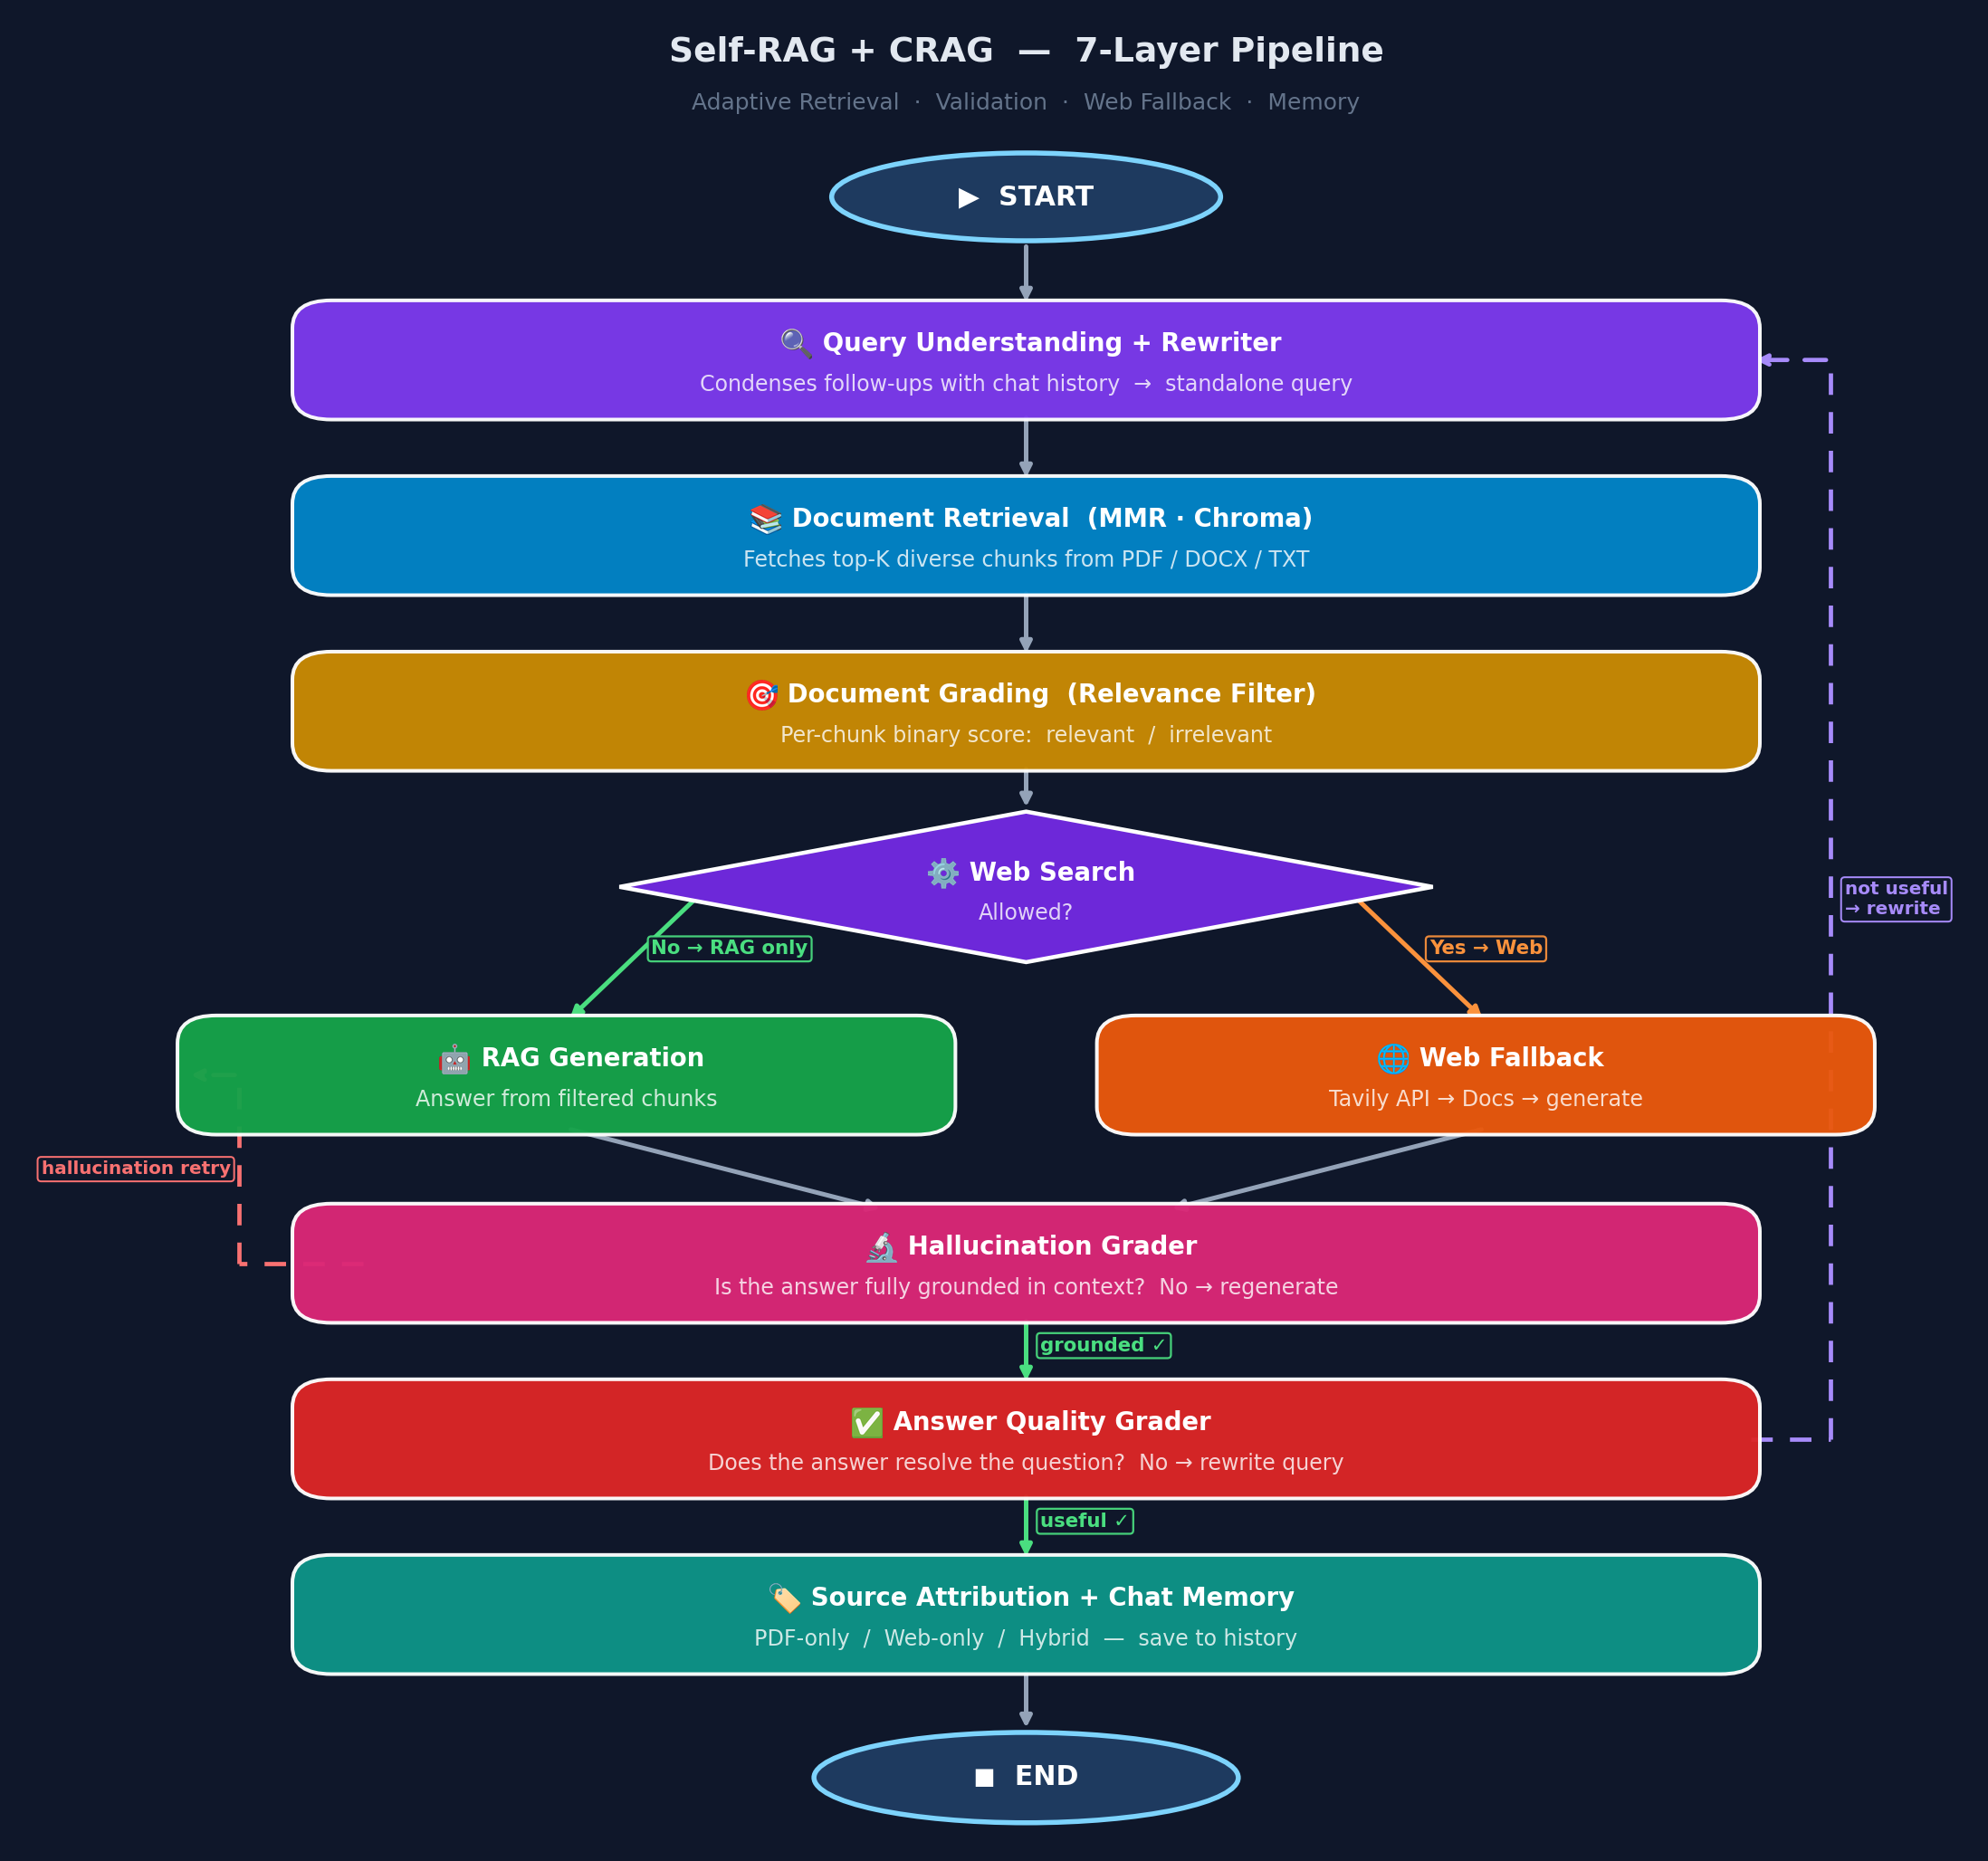

In [42]:
"""
Self-RAG + CRAG — 7-Layer Pipeline
Runs on Kaggle (matplotlib + Pillow pre-installed).

Emoji approach:
  - Each node title is drawn as "      Title" (leading spaces = placeholder gap)
  - After rendering, matplotlib's get_window_extent() gives the exact pixel
    position of that gap, and PIL pastes the NotoColorEmoji glyph there
  - Result: "🔍 Query Understanding + Rewriter" — emoji inline, text centered
"""

import io, os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageFont, ImageDraw

# ── Config ────────────────────────────────────────────────────────────────────
DPI             = 180
FIG_W, FIG_H    = 14, 25
BG              = "#0f172a"
BG_RGB          = np.array([15, 23, 42])
# Auto-detect NotoColorEmoji font across Kaggle / Colab / Ubuntu / Debian
def _find_emoji_font():
    import os, glob
    candidates = [
        "/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf",        # Ubuntu/Debian
        "/usr/share/fonts/noto-color-emoji/NotoColorEmoji.ttf",     # some Debian
        "/usr/share/fonts/google-noto-emoji/NotoColorEmoji.ttf",    # Fedora/RHEL
        "/usr/share/fonts/NotoColorEmoji.ttf",                      # flat install
        "/usr/local/share/fonts/NotoColorEmoji.ttf",                # manual install
        "/opt/conda/share/fonts/NotoColorEmoji.ttf",                # Kaggle conda
        "/root/.fonts/NotoColorEmoji.ttf",
    ]
    # Also glob-search common roots
    for pattern in [
        "/usr/share/fonts/**/NotoColorEmoji.ttf",
        "/usr/local/share/fonts/**/NotoColorEmoji.ttf",
        "/opt/conda/**/NotoColorEmoji.ttf",
    ]:
        candidates += glob.glob(pattern, recursive=True)

    for path in candidates:
        if os.path.isfile(path):
            return path

    # Last resort: download to /tmp
    try:
        import urllib.request
        url  = ("https://github.com/googlefonts/noto-emoji/raw/main/fonts/"
                "NotoColorEmoji.ttf")
        dest = "/tmp/NotoColorEmoji.ttf"
        if not os.path.isfile(dest):
            print("Downloading NotoColorEmoji.ttf …")
            urllib.request.urlretrieve(url, dest)
        return dest
    except Exception as e:
        raise OSError(
            "NotoColorEmoji.ttf not found. "
            "Install it with:  apt-get install -y fonts-noto-color-emoji"
        ) from e

EMOJI_FONT_PATH = _find_emoji_font()
EMOJI_RENDER_SZ = 109
EMOJI_DISP_PX   = 34          # sized to match 11pt bold text height at 180dpi
EMOJI_GAP       = "      "    # 6 spaces — wide enough for emoji + small margin

C = dict(
    start_end="#1e3a5f", L1="#7c3aed", L2="#0284c7", L3="#ca8a04",
    L4="#16a34a", L4b="#ea580c", L5="#db2777", L6="#dc2626", L7="#0d9488",
    cond="#6d28d9", e_main="#94a3b8", e_yes="#4ade80",
    e_no="#f87171", e_web="#fb923c", e_loop="#a78bfa",
)

Y = dict(start=22.5, L1=21.2, L2=19.8, L3=18.4, cond=17.0,
         L4=15.5, L4b=15.5, L5=14.0, L6=12.6, L7=11.2, end=9.9)
NH, NW, NW2 = 0.85, 8.2, 4.3

# ── Coordinate helper ─────────────────────────────────────────────────────────
def d2p(ax, fig, xd, yd):
    disp  = ax.transData.transform((xd, yd))
    scale = DPI / fig.dpi
    col   = int(round(disp[0] * scale))
    row   = int(round(FIG_H * DPI - disp[1] * scale))
    return col, row

# ── Matplotlib helpers ────────────────────────────────────────────────────────
# We keep a registry of all title Text objects so we can measure them later
_title_texts = []   # list of (Text_obj, emoji_char)

def node(ax, x, y, w, h, emoji, title, sub, color, r=0.22):
    ax.add_patch(FancyBboxPatch(
        (x-w/2, y-h/2), w, h,
        boxstyle=f"round,pad=0.05,rounding_size={r}",
        facecolor=color, edgecolor="#ffffff", linewidth=1.6, zorder=3, alpha=0.96))
    t = ax.text(x, y+0.13, EMOJI_GAP + title, ha="center", va="center",
                fontsize=11, color="#ffffff", fontweight="bold",
                zorder=5, fontfamily="DejaVu Sans")
    _title_texts.append((t, emoji, EMOJI_GAP + title))
    ax.text(x, y-0.20, sub, ha="center", va="center",
            fontsize=9.5, color="#ffffffcc", zorder=5, fontfamily="DejaVu Sans")

def diamond_node(ax, x, y, w, h, emoji, l1, l2, color):
    ax.add_patch(plt.Polygon(
        [[x,y+h/2],[x+w/2,y],[x,y-h/2],[x-w/2,y]],
        closed=True, facecolor=color, edgecolor="#ffffff", linewidth=1.8, zorder=3))
    t = ax.text(x, y+0.11, EMOJI_GAP + l1, ha="center", va="center",
                fontsize=11, color="#ffffff", fontweight="bold",
                zorder=5, fontfamily="DejaVu Sans")
    _title_texts.append((t, emoji, EMOJI_GAP + l1))
    ax.text(x, y-0.21, l2, ha="center", va="center",
            fontsize=9.5, color="#ffffffcc", zorder=5, fontfamily="DejaVu Sans")

def oval(ax, x, y, w, h, label, color):
    ax.add_patch(mpatches.Ellipse(
        (x,y), w, h, facecolor=color, edgecolor="#7dd3fc", linewidth=2.2, zorder=3))
    ax.text(x, y, label, ha="center", va="center",
            fontsize=12, color="#ffffff", fontweight="bold",
            zorder=5, fontfamily="DejaVu Sans")

def arrow(ax, x1, y1, x2, y2, color, label="", dashed=False):
    ls = (0,(5,4)) if dashed else "solid"
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.0, linestyle=ls), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.08, my, label, fontsize=8.5, color=color, fontweight="bold",
                zorder=5, fontfamily="DejaVu Sans",
                bbox=dict(boxstyle="round,pad=0.18", fc=BG, ec=color, lw=0.9, alpha=0.93))

def build(ax):
    _title_texts.clear()

    ax.text(5, 23.65, "Self-RAG + CRAG  \u2014  7-Layer Pipeline",
            ha="center", va="center", fontsize=15, fontweight="bold",
            color="#e2e8f0", fontfamily="DejaVu Sans")
    ax.text(5, 23.25, "Adaptive Retrieval  \u00b7  Validation  \u00b7  Web Fallback  \u00b7  Memory",
            ha="center", va="center", fontsize=10, color="#64748b", fontfamily="DejaVu Sans")

    oval(ax, 5, Y["start"], 2.2, 0.70, "\u25b6  START", C["start_end"])

    node(ax, 5, Y["L1"], NW, NH, "🔍",
         "Query Understanding + Rewriter",
         "Condenses follow-ups with chat history  \u2192  standalone query", C["L1"])
    node(ax, 5, Y["L2"], NW, NH, "📚",
         "Document Retrieval  (MMR \u00b7 Chroma)",
         "Fetches top-K diverse chunks from PDF / DOCX / TXT", C["L2"])
    node(ax, 5, Y["L3"], NW, NH, "🎯",
         "Document Grading  (Relevance Filter)",
         "Per-chunk binary score:  relevant  /  irrelevant", C["L3"])

    diamond_node(ax, 5, Y["cond"], 4.6, 1.2, "⚙️", "Web Search", "Allowed?", C["cond"])

    node(ax, 2.4, Y["L4"],  NW2, NH, "🤖",
         "RAG Generation",
         "Answer from filtered chunks", C["L4"])
    node(ax, 7.6, Y["L4b"], NW2, NH, "🌐",
         "Web Fallback",
         "Tavily API \u2192 Docs \u2192 generate", C["L4b"])

    node(ax, 5, Y["L5"], NW, NH, "🔬",
         "Hallucination Grader",
         "Is the answer fully grounded in context?  No \u2192 regenerate", C["L5"])
    node(ax, 5, Y["L6"], NW, NH, "✅",
         "Answer Quality Grader",
         "Does the answer resolve the question?  No \u2192 rewrite query", C["L6"])
    node(ax, 5, Y["L7"], NW, NH, "🏷️",
         "Source Attribution + Chat Memory",
         "PDF-only  /  Web-only  /  Hybrid  \u2014  save to history", C["L7"])

    oval(ax, 5, Y["end"], 2.4, 0.72, "\u25fc  END", C["start_end"])

    hh = NH/2
    arrow(ax, 5, Y["start"]-0.36, 5, Y["L1"]+hh,     C["e_main"])
    arrow(ax, 5, Y["L1"]-hh,      5, Y["L2"]+hh,     C["e_main"])
    arrow(ax, 5, Y["L2"]-hh,      5, Y["L3"]+hh,     C["e_main"])
    arrow(ax, 5, Y["L3"]-hh,      5, Y["cond"]+0.60, C["e_main"])
    arrow(ax, 3.2, Y["cond"],  2.4, Y["L4"]+hh,  C["e_yes"], "No \u2192 RAG only")
    arrow(ax, 6.8, Y["cond"],  7.6, Y["L4b"]+hh, C["e_web"], "Yes \u2192 Web")
    arrow(ax, 2.4, Y["L4"]-hh,  4.2, Y["L5"]+hh, C["e_main"])
    arrow(ax, 7.6, Y["L4b"]-hh, 5.8, Y["L5"]+hh, C["e_main"])
    arrow(ax, 5, Y["L5"]-hh, 5, Y["L6"]+hh, C["e_yes"], "grounded \u2713")
    arrow(ax, 5, Y["L6"]-hh, 5, Y["L7"]+hh, C["e_yes"], "useful \u2713")
    arrow(ax, 5, Y["L7"]-hh, 5, Y["end"]+0.36, C["e_main"])

    lx = 0.55
    ax.plot([1.25,lx],[Y["L5"],Y["L5"]], color=C["e_no"],lw=1.9,linestyle=(0,(5,4)),zorder=2)
    ax.plot([lx,  lx],[Y["L5"],Y["L4"]], color=C["e_no"],lw=1.9,linestyle=(0,(5,4)),zorder=2)
    ax.annotate("", xy=(2.4-NW2/2,Y["L4"]), xytext=(lx,Y["L4"]),
                arrowprops=dict(arrowstyle="-|>",color=C["e_no"],lw=1.9,linestyle=(0,(5,4))),zorder=2)
    ax.text(lx-0.05,(Y["L5"]+Y["L4"])/2,"hallucination retry",
            fontsize=8,color=C["e_no"],fontweight="bold",va="center",ha="right",
            fontfamily="DejaVu Sans",
            bbox=dict(boxstyle="round,pad=0.2",fc=BG,ec=C["e_no"],lw=0.8))
    rx = 9.55
    ax.plot([5+NW/2,rx],[Y["L6"],Y["L6"]],color=C["e_loop"],lw=1.9,linestyle=(0,(5,4)),zorder=2)
    ax.plot([rx,    rx],[Y["L6"],Y["L1"]],color=C["e_loop"],lw=1.9,linestyle=(0,(5,4)),zorder=2)
    ax.annotate("", xy=(5+NW/2,Y["L1"]), xytext=(rx,Y["L1"]),
                arrowprops=dict(arrowstyle="-|>",color=C["e_loop"],lw=1.9,linestyle=(0,(5,4))),zorder=2)
    ax.text(rx+0.08,(Y["L6"]+Y["L1"])/2,"not useful\n\u2192 rewrite",
            fontsize=8,color=C["e_loop"],fontweight="bold",va="center",ha="left",
            fontfamily="DejaVu Sans",
            bbox=dict(boxstyle="round,pad=0.2",fc=BG,ec=C["e_loop"],lw=0.8))

# ── Emoji render ──────────────────────────────────────────────────────────────
def render_emoji(char, disp_sz=EMOJI_DISP_PX):
    font = ImageFont.truetype(EMOJI_FONT_PATH, EMOJI_RENDER_SZ)
    tmp  = Image.new("RGBA", (EMOJI_RENDER_SZ+20, EMOJI_RENDER_SZ+20), (0,0,0,0))
    ImageDraw.Draw(tmp).text((4,4), char, font=font, embedded_color=True)
    box = tmp.getbbox()
    if box is None:
        return None
    return tmp.crop(box).resize((disp_sz, disp_sz), Image.LANCZOS)

# ── Crop ──────────────────────────────────────────────────────────────────────
def crop_tight(img, pad_px=40):
    arr  = np.array(img.convert("RGB"))
    mask = np.any(np.abs(arr.astype(int) - BG_RGB) > 12, axis=2)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if not len(rows) or not len(cols):
        return img
    r0,r1 = max(rows[0]-pad_px,0), min(rows[-1]+pad_px, img.height)
    c0,c1 = max(cols[0]-pad_px,0), min(cols[-1]+pad_px, img.width)
    return img.crop((c0,r0,c1,r1))

# ── Main ──────────────────────────────────────────────────────────────────────
def main(out_path="self_rag_pipeline.png"):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
    ax.set_xlim(0,10); ax.set_ylim(0,25); ax.axis("off")
    build(ax)
    fig.canvas.draw()   # must draw before get_window_extent

    renderer = fig.canvas.get_renderer()
    scale    = DPI / fig.dpi

    # Measure each title text's bounding box to find where the gap ends
    emoji_paste_jobs = []
    for (t_obj, emoji_char, full_str) in _title_texts:
        # Full string bbox
        full_bbox = t_obj.get_window_extent(renderer=renderer)
        full_left_disp = full_bbox.x0   # display units (points at fig.dpi=100)
        full_top_disp  = full_bbox.y1   # top in display coords (y increases up)

        # Gap-only bbox: render a temporary text object with just the gap
        t_gap = ax.text(0, -99, EMOJI_GAP, ha="left", va="center",
                        fontsize=11, color="#ffffff", fontweight="bold",
                        fontfamily="DejaVu Sans", alpha=0)  # invisible
        fig.canvas.draw()
        gap_bbox = t_gap.get_window_extent(renderer=renderer)
        gap_w_disp = gap_bbox.width
        t_gap.remove()

        # Gap occupies display x: [full_left_disp, full_left_disp + gap_w_disp]
        # Center emoji horizontally in the gap
        gap_center_disp_x = full_left_disp + gap_w_disp / 2
        # Center emoji vertically on the title row
        title_center_disp_y = (full_bbox.y0 + full_bbox.y1) / 2

        # Convert to pixel coords (no bbox_inches, so no crop offset)
        col = int(round(gap_center_disp_x * scale))
        row = int(round(FIG_H * DPI - title_center_disp_y * scale))
        emoji_paste_jobs.append((emoji_char, col, row))

    # Save the matplotlib render
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=DPI, bbox_inches=None, pad_inches=0,
                facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    result = Image.open(buf).convert("RGBA")

    # Paste emojis at the measured positions
    sz = EMOJI_DISP_PX
    for (emoji_char, col, row) in emoji_paste_jobs:
        glyph = render_emoji(emoji_char)
        if glyph is None:
            continue
        left = col - sz // 2
        top  = row - sz // 2
        px = max(left, 0);  py = max(top, 0)
        cx = px - left;     cy = py - top
        w  = min(sz - cx, result.width  - px)
        h  = min(sz - cy, result.height - py)
        if w > 0 and h > 0:
            g_crop = glyph.crop((cx, cy, cx+w, cy+h))
            result.paste(g_crop, (px, py), g_crop)

    final = crop_tight(result.convert("RGB"), pad_px=40)
    os.makedirs(os.path.dirname(os.path.abspath(out_path)), exist_ok=True)
    final.save(out_path, dpi=(DPI,DPI))
    print(f"Saved -> {out_path}  ({final.width} x {final.height} px)")
    return final

if __name__ == "__main__":
    img = main("/kaggle/working/self_rag_pipeline.png")
    try:
        from IPython.display import display as ipy_display
        ipy_display(img)
    except ImportError:
        pass

## 13. 💬 Conversation Memory

Chat history is maintained across turns so the model understands follow-up questions like *"What did you mean by that?"* or *"Tell me more about the second point."*

- `chat_history` stores `(role, message)` tuples
- `format_history()` converts it to a readable string for the prompt
- History is reset when a new PDF is loaded or the user clicks **Clear**


In [22]:
from collections import deque

# In-memory conversation history (list of dicts)
chat_history = []
MAX_HISTORY_TURNS = 10  # keep last N turns to avoid overflowing context

def format_history(history: list) -> str:
    """Convert chat history list to a formatted string for the LLM prompt."""
    if not history:
        return "No previous conversation."
    lines = []
    for turn in history[-MAX_HISTORY_TURNS:]:
        lines.append(f"User: {turn['user']}")
        lines.append(f"Assistant: {turn['assistant']}")
    return "\n".join(lines)

def add_to_history(user_msg: str, assistant_msg: str):
    """Append a turn to chat history."""
    chat_history.append({"user": user_msg, "assistant": assistant_msg})

def clear_history():
    """Reset conversation history."""
    global chat_history
    chat_history = []

print("Conversation memory defined")

Conversation memory defined


## 14. 🔁 Run Self-RAG Pipeline

`run_self_rag()` is the main entry point:
1. Condenses the question using chat history (Layer 1)
2. Streams the LangGraph pipeline
3. If PDF retrieval fails → automatically triggers web search (Layer 4b)
4. Attaches source label: **📄 PDF**, **🌐 Web**, or **🔀 Hybrid**
5. Saves the turn to chat history (Layer 7)


In [23]:
def run_self_rag(question: str, force_web: bool = False) -> dict:
    """
    Run the full Self-RAG + CRAG pipeline.
    
    Args:
        question:  Raw user question
        force_web: If True, always supplement with web results
    Returns:
        dict with keys: answer, steps, retries, source_label
    """
    if _retriever is None:
        return {
            "answer":       "⚠️ Please upload a PDF first.",
            "steps":        ["❌ No PDF loaded"],
            "retries":      0,
            "source_label": "none",
        }

    # Layer 1: Condense question with history for better retrieval
    history_str    = format_history(chat_history)
    condensed_q    = question

    if chat_history:
        try:
            condensed_q = question_rewriter.invoke({
                "question": question,
                "history":  history_str,
            })
            condensed_q = re.sub(
                r'^(improved question:|standalone question:|rewritten:|answer:|question:)\s*',
                '', condensed_q.strip(), flags=re.IGNORECASE
            ).strip()
        except Exception:
            condensed_q = question  # fallback to original if rewriter fails

    initial_state = {
        "question":          condensed_q,
        "original_question": question,
        "generation":        "",
        "documents":         [],
        "retry_count":       0,
        "used_web":          False,
        "steps":             [f"💬 **Layer 1 — Query Understanding:** "
                              f"`{condensed_q}`" if condensed_q != question
                              else f"💬 **Layer 1 — Query Understanding:** No history context needed"],
        "history":           history_str,
    }

    # If user forces web search, inject web docs before the graph runs
    if force_web and WEB_SEARCH_ENABLED:
        web_docs = web_search_fallback(condensed_q)
        if web_docs:
            initial_state["documents"] = web_docs
            initial_state["used_web"]  = True
            initial_state["steps"].append(
                f"🌐 **Force Web Search:** Retrieved {len(web_docs)} results"
            )

    # Run LangGraph
    final_state = None
    try:
        for output in app.stream(initial_state):
            for _, state in output.items():
                final_state = state
    except Exception as e:
        return {
            "answer":       f"❌ Pipeline error: {e}",
            "steps":        initial_state["steps"],
            "retries":      0,
            "source_label": "error",
        }

    if final_state is None:
        return {
            "answer":       "❌ No output from pipeline.",
            "steps":        [],
            "retries":      0,
            "source_label": "none",
        }

    answer  = final_state.get("generation", "No answer generated.")
    steps   = final_state.get("steps", [])
    retries = final_state.get("retry_count", 0)
    used_web = final_state.get("used_web", False)

    # Layer 7: Source attribution label
    has_pdf = any(
        d.metadata.get("type", "pdf") == "pdf"
        for d in final_state.get("documents", [])
    )
    has_web = used_web or any(
        d.metadata.get("type") == "web"
        for d in final_state.get("documents", [])
    )

    if has_pdf and has_web:
        source_label = "hybrid"
    elif has_web:
        source_label = "web"
    elif has_pdf:
        source_label = "pdf"
    else:
        source_label = "none"

    steps.append(
        f"🏷️ **Layer 7 — Source Attribution:** "
        f"{'📄 PDF + 🌐 Web (Hybrid)' if source_label == 'hybrid' else '🌐 Web only' if source_label == 'web' else '📄 PDF only'}"
    )

    # Save to chat memory
    add_to_history(question, answer)

    return {
        "answer":       answer,
        "steps":        steps,
        "retries":      retries,
        "source_label": source_label,
    }

print("run_self_rag() defined")

run_self_rag() defined


## 15. Test Self Rag

In [24]:
## 🧪 Pipeline Test Cell — Dynamic File + Input

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pathlib, time, os, io

# ── Widgets ───────────────────────────────────────────────────────────────────
uploader = widgets.FileUpload(
    accept=".pdf,.docx,.doc,.txt",
    multiple=False,
    description="📂 Upload",
    layout=widgets.Layout(width="160px"),
)

process_btn_w = widgets.Button(
    description="⚡ Process",
    button_style="success",
    layout=widgets.Layout(width="120px"),
)

question_input = widgets.Textarea(
    placeholder="Type your question and press Ask...",
    layout=widgets.Layout(width="100%", height="70px"),
    disabled=True,
)

web_toggle = widgets.ToggleButton(
    value=False,
    description="🌐 Web OFF",
    button_style="",
    layout=widgets.Layout(width="120px"),
)

ask_btn = widgets.Button(
    description="▶ Ask",
    button_style="primary",
    disabled=True,
    layout=widgets.Layout(width="100px"),
)

clear_btn_w = widgets.Button(
    description="🗑 Clear",
    button_style="warning",
    layout=widgets.Layout(width="100px"),
)

status_out  = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #1e3a5f",
        border_radius="8px",
        padding="10px",
        min_height="60px",
        background_color="#0e1829",
    )
)

chat_out = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #1e3a5f",
        border_radius="8px",
        padding="12px",
        min_height="200px",
        max_height="600px",
        overflow_y="auto",
        background_color="#0e1829",
    )
)


# ── Web toggle label ──────────────────────────────────────────────────────────
def on_web_toggle(change):
    if web_toggle.value:
        web_toggle.description  = "🌐 Web ON"
        web_toggle.button_style = "info"
    else:
        web_toggle.description  = "🌐 Web OFF"
        web_toggle.button_style = ""

web_toggle.observe(on_web_toggle, names="value")


# ── Save uploaded file robustly ───────────────────────────────────────────────
def save_uploaded_file():
    """
    Handles both old ipywidgets (<8) and new (>=8) FileUpload formats.
    Returns (fpath, fname) or (None, None) on failure.
    """
    if not uploader.value:
        return None, None

    try:
        # ipywidgets >= 8: uploader.value is a tuple of dicts
        if isinstance(uploader.value, (list, tuple)):
            item  = uploader.value[0]
            fname = item["name"]
            data  = bytes(item["content"])
        # ipywidgets < 8: uploader.value is a dict keyed by filename
        elif isinstance(uploader.value, dict):
            fname = list(uploader.value.keys())[0]
            raw   = uploader.value[fname]
            # content may be bytes or a dict with 'content' key
            data  = bytes(raw["content"]) if isinstance(raw, dict) else bytes(raw)
        else:
            return None, None

        fpath = f"/tmp/{fname}"
        with open(fpath, "wb") as f:
            f.write(data)
        return fpath, fname

    except Exception as e:
        return None, str(e)


# ── Process file ──────────────────────────────────────────────────────────────
def on_process(b):
    status_out.clear_output()
    with status_out:
        fpath, fname = save_uploaded_file()

        if fpath is None:
            print(f"❌ {fname or 'No file uploaded — use the Upload button first.'}")
            return

        if not os.path.exists(fpath):
            print(f"❌ Could not save file: {fname}")
            return

        ext = pathlib.Path(fpath).suffix.lower()
        if ext not in [".pdf", ".docx", ".doc", ".txt"]:
            print(f"❌ Unsupported format: {ext}\n   Use: PDF, DOCX, DOC, TXT")
            return

        print(f"⏳ Processing `{fname}`...")
        try:
            pages, chunks = build_vectorstore_from_file(fpath)
            clear_history()
            print(f"✅ Ready!\n")
            print(f"   📄 File     : {fname}")
            print(f"   📖 Pages    : {pages}")
            print(f"   ✂️  Chunks   : {chunks}")
            print(f"   🔎 Retrieval: MMR top-{TOP_K_DOCS}")
            print(f"   🤖 Model    : {GENERATOR_MODEL}")
            print(f"   🌐 Web      : {'Tavily ready' if WEB_SEARCH_ENABLED else 'disabled'}")

            question_input.disabled = False
            ask_btn.disabled        = False
            question_input.placeholder = f"Ask anything about {fname}..."

        except Exception as e:
            print(f"❌ Error building vector store:\n   {e}")


# ── Ask pipeline ──────────────────────────────────────────────────────────────
def on_ask(b):
    question = question_input.value.strip()
    if not question:
        return
    if ask_btn.disabled:
        return

    # Lock input while processing
    ask_btn.disabled       = True
    question_input.disabled = True
    question_input.value   = ""

    with chat_out:
        print(f"\n{'━'*58}")
        print(f"  👤  {question}")
        print(f"{'━'*58}")
        print(f"  ⏳  Running pipeline...")

    try:
        t0     = time.time()
        result = run_self_rag(question, force_web=web_toggle.value)
        elapsed = time.time() - t0

        answer       = result["answer"]
        steps        = result["steps"]
        retries      = result["retries"]
        source_label = result["source_label"]

        source_map = {
            "pdf":    "📄 Document only",
            "web":    "🌐 Web search only",
            "hybrid": "🔀 Document + Web",
            "none":   "⚠️  No context found",
            "error":  "❌ Pipeline error",
        }

        with chat_out:
            print(f"\n  🤖  ANSWER\n")
            # Print answer wrapped at 56 chars
            import textwrap
            for line in answer.split("\n"):
                for wrapped in textwrap.wrap(line, width=56) or [""]:
                    print(f"  {wrapped}")
            print(f"\n  {'─'*54}")
            print(f"  ⏱  {elapsed:.1f}s  ·  🔄 {retries} rewrite(s)  ·  {source_map.get(source_label, source_label)}")
            print(f"\n  🔬  REASONING TRACE")
            for i, step in enumerate(steps, 1):
                clean = step.replace("**", "").replace("`", "").replace("*", "")
                for j, wrapped in enumerate(textwrap.wrap(clean, width=52) or [clean]):
                    prefix = f"  {i:>2}. " if j == 0 else "      "
                    print(f"{prefix}{wrapped}")
            print(f"{'━'*58}\n")

    except Exception as e:
        with chat_out:
            print(f"\n  ❌ Pipeline error: {e}\n")

    finally:
        # Unlock input
        ask_btn.disabled        = False
        question_input.disabled = False


# ── Clear ─────────────────────────────────────────────────────────────────────
def on_clear(b):
    chat_out.clear_output()
    clear_history()
    with chat_out:
        print("🗑  Cleared.\n")


# ── Wire ──────────────────────────────────────────────────────────────────────
process_btn_w.on_click(on_process)
ask_btn.on_click(on_ask)
clear_btn_w.on_click(on_clear)
def on_key(change):
    val = change["new"]
    if val.endswith("\n") and not val.endswith("\n\n"):
        on_ask(None)

question_input.observe(on_key, names="value")


# ── Layout ────────────────────────────────────────────────────────────────────
display(HTML("""
<div style="font-family:'JetBrains Mono',monospace; padding:16px 0 8px">
  <span style="font-size:1.1rem; font-weight:600; color:#60a5fa">🧪 Pipeline Test</span>
  <span style="font-size:0.75rem; color:#64748b; margin-left:12px">No Gradio — direct pipeline access</span>
</div>
"""))

display(HTML("<div style='font-size:0.78rem;color:#94a3b8;font-family:monospace;margin-bottom:6px'>① Upload your file then click Process</div>"))
display(widgets.HBox(
    [uploader, process_btn_w],
    layout=widgets.Layout(gap="10px", align_items="center")
))
display(status_out)

display(HTML("<div style='font-size:0.78rem;color:#94a3b8;font-family:monospace;margin:12px 0 6px'>② Ask questions — press <b style='color:#60a5fa'>Enter</b> once to submit (double Enter = new line)</div>"))
display(question_input)
display(widgets.HBox(
    [ask_btn, web_toggle, clear_btn_w],
    layout=widgets.Layout(gap="10px", margin="8px 0", align_items="center")
))

display(HTML("<div style='font-size:0.78rem;color:#94a3b8;font-family:monospace;margin:8px 0 6px'>③ Output</div>"))
display(chat_out)

with chat_out:
    print("📭 Upload and process a file to begin.\n")

Output(layout=Layout(border_bottom='1px solid #1e3a5f', border_left='1px solid #1e3a5f', border_right='1px sol…

Textarea(value='', disabled=True, layout=Layout(height='70px', width='100%'), placeholder='Type your question …

Output(layout=Layout(border_bottom='1px solid #1e3a5f', border_left='1px solid #1e3a5f', border_right='1px sol…

## 16. 🖥️ Streamlit UI

The cell below auto-finds a free port, writes `streamlit_app.py`, installs Streamlit if needed, and launches the server with a public localtunnel URL.

**Run all prior cells first** so the pipeline functions are in the kernel's global scope.


In [25]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 75.7 MB/s eta 0:00:00:00:0100:01


In [26]:
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dill"])

In [27]:
import os, pathlib
import __main__ as main

# ── Capture live config ───────────────────────────────────────────────────────
GRADER_MODEL    = main.GRADER_MODEL
GENERATOR_MODEL = main.GENERATOR_MODEL
EMBED_MODEL     = main.EMBED_MODEL
MAX_RETRIES     = main.MAX_RETRIES
CHUNK_SIZE      = main.CHUNK_SIZE
CHUNK_OVERLAP   = main.CHUNK_OVERLAP
TOP_K_DOCS      = main.TOP_K_DOCS
MIN_RELEVANT    = main.MIN_RELEVANT
TAVILY_API_KEY  = os.environ.get("TAVILY_API_KEY", "")

# ── Write pipeline.py ─────────────────────────────────────────────────────────
pipeline_py = f'''# pipeline.py — auto-generated
import os, re, json, pathlib
from typing import TypedDict, List

GRADER_MODEL       = {GRADER_MODEL!r}
GENERATOR_MODEL    = {GENERATOR_MODEL!r}
EMBED_MODEL        = {EMBED_MODEL!r}
MAX_RETRIES        = {MAX_RETRIES}
CHUNK_SIZE         = {CHUNK_SIZE}
CHUNK_OVERLAP      = {CHUNK_OVERLAP}
TOP_K_DOCS         = {TOP_K_DOCS}
MIN_RELEVANT       = {MIN_RELEVANT}
TAVILY_API_KEY     = os.environ.get("TAVILY_API_KEY", {TAVILY_API_KEY!r})
WEB_SEARCH_ENABLED = bool(TAVILY_API_KEY)
''' + r'''
from langchain_ollama import OllamaLLM
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langgraph.graph import END, StateGraph

print("Initialising LLMs...", flush=True)
llm_grader = OllamaLLM(
    model=GRADER_MODEL, temperature=0,
    base_url="http://127.0.0.1:11434", num_gpu=2, num_ctx=4096, format="json"
)
llm_generator = OllamaLLM(
    model=GENERATOR_MODEL, temperature=0.1,
    base_url="http://127.0.0.1:11434", num_gpu=2, num_ctx=8192
)
embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    encode_kwargs={"normalize_embeddings": True}
)
print("LLMs ready.", flush=True)

vectorstore = None
retriever   = None
pdf_status  = {"loaded": False, "name": "", "pages": 0, "chunks": 0}

# ── Chains ────────────────────────────────────────────────────────────────────
retrieval_grader = (
    ChatPromptTemplate.from_messages([
        ("system",
         "You are a strict document relevance grader. Given a question and a document chunk, "
         "decide if the chunk contains information relevant to answering the question. "
         "Consider both keyword matches AND semantic meaning. "
         "Respond ONLY with valid JSON with key binary_score and value yes or no. No other text."),
        ("human", "Question: {question}\nDocument chunk:{document}\nIs this chunk relevant?"),
    ])
    | llm_grader | StrOutputParser()
)

rag_chain = (
    ChatPromptTemplate.from_messages([
        ("system",
         "You are a precise, helpful assistant answering questions based ONLY on provided context.\n"
         "Rules:\n"
         "- Use ONLY the provided context. Never use prior knowledge.\n"
         "- Structure your answer clearly with bullet points.\n"
         "- For EVERY fact you state, cite the exact source at the end of that bullet like: [Doc p.X] or [Web: title].\n"
         "- Start each bullet with a dash -\n"
         "- Use **bold** for key terms.\n"
         "- End with a 'Sources used:' line listing all cited pages/URLs.\n"
         "- If context does not contain enough info, say: 'The document does not contain enough information to answer this.'"),
        ("human", "Conversation history:\n{history}\n\nContext:\n{context}\n\nQuestion: {question}"),
    ])
    | llm_generator | StrOutputParser()
)

hallucination_grader = (
    ChatPromptTemplate.from_messages([
        ("system",
         "You are a hallucination detector for RAG systems. Check if every claim in the generated "
         "answer is supported by the source documents. "
         "Respond ONLY with valid JSON with key binary_score and value yes if grounded or no if hallucinated."),
        ("human", "Source documents:\n{documents}\n\nGenerated answer:\n{generation}\nIs the answer fully grounded?"),
    ])
    | llm_grader | StrOutputParser()
)

answer_grader = (
    ChatPromptTemplate.from_messages([
        ("system",
         "You are an answer quality assessor. Decide if the answer actually resolves the user "
         "question meaningfully. Partial but relevant answers count as yes. "
         "Respond ONLY with valid JSON with key binary_score and value yes if useful or no if not useful."),
        ("human", "Question: {question}\n\n{generation}\nDoes this answer resolve the question?"),
    ])
    | llm_grader | StrOutputParser()
)

question_rewriter = (
    ChatPromptTemplate.from_messages([
        ("system",
         "You are a query optimization expert for vector-store retrieval. Given a conversation "
         "history and a follow-up question, produce ONE improved standalone query. "
         "Return ONLY the improved question. No explanation, no prefix."),
        ("human", "Conversation history:\n{history}\n\nFollow-up question: {question}\nStandalone improved question:"),
    ])
    | llm_generator | StrOutputParser()
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_binary_score(text: str) -> str:
    text = text.strip()
    try:
        val = str(json.loads(text).get("binary_score", "")).strip().lower()
        if val in ("yes", "no"):
            return val
    except Exception:
        pass
    m = re.search(r'["\']?binary_score["\']?\s*:\s*["\']?(yes|no)', text.lower())
    if m:
        return m.group(1)
    lower = text.lower()
    if "yes" in lower and "no" not in lower:
        return "yes"
    if "no" in lower and "yes" not in lower:
        return "no"
    return "yes"


def format_docs(docs: list) -> str:
    parts = []
    for i, d in enumerate(docs, 1):
        src  = d.metadata.get("source", "?")
        page = d.metadata.get("page", "")
        kind = d.metadata.get("type", "pdf")
        label = f"[Web: {src}]" if kind == "web" else f"[Doc p.{page}]"
        parts.append(f"{label}\n{d.page_content}")
    return "\n---\n".join(parts)


def web_search_fallback(query: str, max_results: int = 5) -> list:
    if not WEB_SEARCH_ENABLED:
        print("Web search disabled — no TAVILY_API_KEY")
        return []
    try:
        from tavily import TavilyClient
        client  = TavilyClient(api_key=TAVILY_API_KEY)
        results = client.search(query, max_results=max_results)
        docs = []
        for item in results.get("results", []):
            content = item.get("content") or item.get("snippet") or ""
            url     = item.get("url", "")
            title   = item.get("title", "Web Result")
            if content:
                docs.append(Document(
                    page_content=f"[{title}]\n{content}",
                    metadata={"source": url, "type": "web", "title": title}
                ))
        print(f"Tavily returned {len(docs)} web results")
        return docs
    except Exception as e:
        print(f"Web search error: {e}")
        return []


def build_vectorstore_from_file(filepath: str):
    global vectorstore, retriever, pdf_status
    ext = pathlib.Path(filepath).suffix.lower()
    if ext == ".pdf":
        loader = PyPDFLoader(filepath)
        pages  = loader.load()
    elif ext in (".docx", ".doc"):
        from langchain_community.document_loaders import Docx2txtLoader
        loader = Docx2txtLoader(filepath)
        pages  = loader.load()
    elif ext == ".txt":
        from langchain_community.document_loaders import TextLoader
        loader = TextLoader(filepath, encoding="utf-8")
        pages  = loader.load()
    else:
        raise ValueError(f"Unsupported file type: {ext}")

    print(f"{len(pages)} pages/sections loaded")
    splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP,
    )
    chunks = splitter.split_documents(pages)
    print(f"{len(chunks)} chunks created")

    if vectorstore is not None:
        try:
            vectorstore.delete_collection()
        except Exception:
            pass

    vectorstore = Chroma.from_documents(
        documents=chunks,
        collection_name="self-rag-store",
        embedding=embeddings,
    )
    retriever = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": TOP_K_DOCS, "fetch_k": TOP_K_DOCS + 3},
    )
    pdf_status = {"loaded": True, "name": pathlib.Path(filepath).name,
                  "pages": len(pages), "chunks": len(chunks)}
    print(f"Vector store ready — MMR top-{TOP_K_DOCS}")
    return len(pages), len(chunks)


def build_vectorstore_from_pdf(path):
    return build_vectorstore_from_file(path)

# ── GraphState ────────────────────────────────────────────────────────────────
class GraphState(TypedDict):
    question:          str
    original_question: str
    generation:        str
    documents:         List[object]
    retry_count:       int
    used_web:          bool
    steps:             List[str]
    history:           str

# ── Graph Nodes ───────────────────────────────────────────────────────────────
def retrieve(state: GraphState) -> GraphState:
    question = state["question"]
    steps    = state.get("steps", [])
    if retriever is None:
        steps.append("No PDF loaded — upload a PDF first")
        return {**state, "documents": [], "steps": steps}
    documents = retriever.invoke(question)
    steps.append(f"Layer 2 Retrieve: Fetched {len(documents)} candidate chunks from PDF")
    return {**state, "documents": documents, "steps": steps}


def grade_documents(state: GraphState) -> GraphState:
    question  = state["question"]
    documents = state["documents"]
    steps     = state.get("steps", [])
    filtered, kept = [], 0
    for doc in documents:
        raw   = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        grade = parse_binary_score(raw)
        if grade == "yes":
            kept += 1
            filtered.append(doc)
    steps.append(f"Layer 3 Grade Docs: {kept}/{len(documents)} chunks are relevant")
    return {**state, "documents": filtered, "steps": steps}


def web_search_node(state: GraphState) -> GraphState:
    question = state["question"]
    steps    = state.get("steps", [])
    webdocs  = web_search_fallback(question)
    if webdocs:
        steps.append(f"Layer 4b Web Fallback: Retrieved {len(webdocs)} web results via Tavily")
    else:
        steps.append("Layer 4b Web Fallback: Web search returned no results")
    return {**state, "documents": webdocs, "used_web": True, "steps": steps}


def generate(state: GraphState) -> GraphState:
    question   = state["question"]
    documents  = state["documents"]
    history    = state.get("history", "No previous conversation.")
    steps      = state.get("steps", [])
    context    = format_docs(documents) if documents else "No context available."
    generation = rag_chain.invoke({"context": context, "question": question, "history": history})
    steps.append(f"Layer 4 Generate: Answer produced ({len(generation.split())} words)")
    return {**state, "generation": generation, "steps": steps}


def transform_query(state: GraphState) -> GraphState:
    question    = state["question"]
    history     = state.get("history", "")
    steps       = state.get("steps", [])
    retry_count = state.get("retry_count", 0) + 1
    raw_rewrite = question_rewriter.invoke({"question": question, "history": history})
    better_q    = re.sub(
        r'^(improved question|standalone question|rewritten|answer)[:\s]*',
        '', raw_rewrite.strip(), flags=re.IGNORECASE
    ).strip()
    label = better_q[:75] + "..." if len(better_q) > 75 else better_q
    steps.append(f"Layer 1 Rewrite: attempt {retry_count}/{MAX_RETRIES} → {label}")
    return {**state, "question": better_q, "retry_count": retry_count, "steps": steps}


def decide_to_generate(state: GraphState) -> str:
    docs        = state.get("documents", [])
    retry_count = state.get("retry_count", 0)
    used_web    = state.get("used_web", False)
    if len(docs) >= MIN_RELEVANT:
        return "generate"
    if not used_web and WEB_SEARCH_ENABLED:
        return "websearch"
    if retry_count < MAX_RETRIES:
        return "transform_query"
    return "generate"


def grade_generation_quality(state: GraphState) -> str:
    question   = state["question"]
    documents  = state["documents"]
    generation = state["generation"]
    steps      = state.get("steps", [])
    retry      = state.get("retry_count", 0)

    raw_h    = hallucination_grader.invoke({
        "documents":  format_docs(documents) if documents else "No context.",
        "generation": generation
    })
    grounded = parse_binary_score(raw_h) == "yes"
    if not grounded:
        if retry >= MAX_RETRIES:
            steps.append("Layer 5 Hallucination: Detected but max retries reached — returning best answer")
            state["steps"] = steps
            return "useful"
        steps.append("Layer 5 Hallucination: Answer not grounded — regenerating...")
        state["steps"] = steps
        return "not supported"
    steps.append("Layer 5 Hallucination: Answer fully grounded ✓")

    raw_a  = answer_grader.invoke({"question": question, "generation": generation})
    useful = parse_binary_score(raw_a) == "yes"
    if useful:
        steps.append("Layer 6 Quality: Answer resolves the question ✓")
        state["steps"] = steps
        return "useful"
    if retry >= MAX_RETRIES:
        steps.append("Layer 6 Quality: Not ideal but max retries reached — returning best answer")
        state["steps"] = steps
        return "useful"
    steps.append("Layer 6 Quality: Answer incomplete — rewriting query...")
    state["steps"] = steps
    return "not useful"

# ── Compile Graph ─────────────────────────────────────────────────────────────
workflow = StateGraph(GraphState)
workflow.add_node("retrieve",        retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("web_search",      web_search_node)
workflow.add_node("generate",        generate)
workflow.add_node("transform_query", transform_query)
workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {"generate": "generate", "websearch": "web_search", "transform_query": "transform_query"}
)
workflow.add_edge("web_search",      "generate")
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate", grade_generation_quality,
    {"useful": END, "not useful": "transform_query", "not supported": "generate"}
)
app = workflow.compile()
print("Graph compiled.", flush=True)

# ── Chat History ──────────────────────────────────────────────────────────────
chat_history      = []
MAX_HISTORY_TURNS = 10

def format_history() -> str:
    if not chat_history:
        return "No previous conversation."
    return "\n".join(
        f"User: {u}\nAssistant: {a}" for u, a in chat_history[-MAX_HISTORY_TURNS:]
    )

def add_to_history(user_msg: str, assistant_msg: str):
    chat_history.append((user_msg, assistant_msg))
    if len(chat_history) > MAX_HISTORY_TURNS:
        chat_history.pop(0)

def clear_history():
    chat_history.clear()

# ── Main Entrypoint ───────────────────────────────────────────────────────────
def run_self_rag(question: str, force_web: bool = False) -> dict:
    history = format_history()
    initial_state = GraphState(
        question=question,
        original_question=question,
        generation="",
        documents=[],
        retry_count=0,
        used_web=force_web,
        steps=[f"Layer 1 Query: '{question[:80]}{'...' if len(question) > 80 else ''}'"],
        history=history,
    )
    if force_web:
        initial_state["steps"].append("Layer 4b Web Search: Force-web enabled by user")

    try:
        final = app.invoke(initial_state)
    except Exception as e:
        return {"answer": f"Pipeline error: {e}", "steps": [f"Error: {e}"],
                "retries": 0, "source_label": "error"}

    answer   = final.get("generation", "No answer generated.")
    steps    = final.get("steps", [])
    retries  = final.get("retry_count", 0)
    docs     = final.get("documents", [])

    if docs:
        types = {d.metadata.get("type", "pdf") for d in docs}
        if "web" in types and "pdf" in types:
            source_label = "hybrid"
        elif "web" in types:
            source_label = "web"
        else:
            source_label = "pdf"
    else:
        source_label = "none"

    steps.append(f"Layer 7 Source Attribution: {source_label.upper()} | {len(docs)} docs used")
    add_to_history(question, answer)
    return {"answer": answer, "steps": steps, "retries": retries, "source_label": source_label}
'''

with open("/kaggle/working/pipeline.py", "w", encoding="utf-8") as f:
    f.write(pipeline_py)
print("pipeline.py written")

# ── Syntax + import check ─────────────────────────────────────────────────────
import ast, subprocess, sys
try:
    ast.parse(pathlib.Path("/kaggle/working/pipeline.py").read_text())
    print("pipeline.py syntax OK ✓")
except SyntaxError as e:
    print(f"SyntaxError: {e}")

r = subprocess.run(
    [sys.executable, "-c",
     "import sys; sys.path.insert(0,'.'); import pipeline; print('pipeline imports OK ✓')"],
    capture_output=True, text=True, cwd="/kaggle/working"
)
print(r.stdout.strip())
if r.returncode != 0:
    print("STDERR:", r.stderr[-2000:])

# ── Write streamlit_app.py ────────────────────────────────────────────────────
streamlit_code = r'''
import os, time, tempfile, re
import streamlit as st

st.set_page_config(page_title="RagMind Assistant", page_icon="🧠",
                   layout="wide", initial_sidebar_state="collapsed")

CSS = """<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;800;900&family=JetBrains+Mono:wght@500;600&display=swap');
:root {
  --bg:#0a0e1a; --card:rgba(13,17,35,0.95); --acc:#7c3aed; --acc2:#a78bfa;
  --cyan:#06b6d4; --green:#10b981; --rose:#f43f5e; --gold:#f59e0b; --teal:#2dd4bf;
  --b0:rgba(124,58,237,0.18); --b1:rgba(124,58,237,0.40); --b2:rgba(124,58,237,0.70);
  --t1:#eef2ff; --t2:#a5b4fc; --t3:#6b7280; --r1:16px; --r2:12px; --r3:8px;
}
html,body,[data-testid="stAppViewContainer"]{background:var(--bg)!important;font-family:Inter,sans-serif!important;color:var(--t1)!important;}
[data-testid="stAppViewContainer"]::before{content:"";position:fixed;inset:0;z-index:0;pointer-events:none;
  background:radial-gradient(ellipse 70% 45% at 5% 5%,rgba(124,58,237,0.12) 0%,transparent 60%),
             radial-gradient(ellipse 55% 40% at 95% 90%,rgba(6,182,212,0.09) 0%,transparent 55%);}
[data-testid="stMain"]{position:relative;z-index:1;}
MainMenu,footer,[data-testid="stToolbar"],[data-testid="stDecoration"]{display:none!important;}
.main .block-container{padding:0 1.4rem 1.5rem!important;max-width:1700px;}

/* HERO */
.hero{text-align:center;padding:1.4rem 1rem 0.6rem;}
.hero-brand{font-size:clamp(2rem,5vw,3.2rem);font-weight:900;letter-spacing:-0.05em;
  background:linear-gradient(135deg,#7c3aed 0%,#a78bfa 35%,#06b6d4 65%,#2dd4bf 100%);
  -webkit-background-clip:text;background-clip:text;-webkit-text-fill-color:transparent;
  filter:drop-shadow(0 0 40px rgba(124,58,237,0.55));}
.hero-sub{font-size:1rem;font-weight:700;color:var(--acc2);margin-top:.35rem;}
.hero-tag{font-size:.80rem;color:var(--t3);margin-top:.25rem;letter-spacing:.05em;}
.hero-line{height:3px;margin:.9rem auto 0;border-radius:2px;max-width:650px;
  background:linear-gradient(90deg,transparent,#7c3aed 20%,#a78bfa 50%,#06b6d4 80%,transparent);}

/* CARDS */
.gc{background:var(--card);border:1.5px solid var(--b0);border-radius:var(--r1);overflow:hidden;backdrop-filter:blur(20px);transition:border-color .25s;}
.gc:hover{border-color:var(--b1);}
.gc-glow{border-color:rgba(124,58,237,0.30)!important;box-shadow:0 0 40px rgba(124,58,237,0.10)!important;}
.ch{display:flex;align-items:center;gap:.55rem;padding:.65rem 1.4rem;
  background:linear-gradient(90deg,rgba(124,58,237,0.16),transparent);
  border-bottom:1.5px solid rgba(124,58,237,0.20);font-size:.75rem;font-weight:800;
  letter-spacing:.18em;text-transform:uppercase;color:var(--acc2);}
.ch::after{content:"";flex:1;height:1px;background:linear-gradient(90deg,rgba(124,58,237,0.25),transparent);margin-left:.5rem;}
.gc-body{padding:1rem 1.4rem 1.2rem;}

/* PIPELINE BUBBLES */
.pipe-outer{display:flex;align-items:center;justify-content:center;flex-wrap:nowrap;
  gap:0;padding:1.2rem .8rem 1rem;overflow-x:auto;width:100%;}
.pipe-outer::-webkit-scrollbar{height:4px;}
.pipe-outer::-webkit-scrollbar-thumb{background:var(--b1);border-radius:2px;}
.pipe-node{display:flex;flex-direction:column;align-items:center;flex-shrink:0;}
.pipe-bubble{width:98px;height:98px;border-radius:50%;display:flex;flex-direction:column;
  align-items:center;justify-content:center;border:2.5px solid;cursor:default;
  transition:transform .25s,box-shadow .3s;gap:2px;}
.pipe-bubble:hover{transform:translateY(-5px) scale(1.08);}
.pb-emoji{font-size:1.6rem;line-height:1;}
.pb-label{font-size:.58rem;font-weight:800;letter-spacing:.04em;text-transform:uppercase;
  text-align:center;color:#fff;line-height:1.2;padding:0 5px;}
.pb1{background:rgba(124,58,237,0.20);border-color:#7c3aed;box-shadow:0 0 20px rgba(124,58,237,0.35);}
.pb2{background:rgba(6,182,212,0.20);border-color:#06b6d4;box-shadow:0 0 20px rgba(6,182,212,0.35);}
.pb3{background:rgba(16,185,129,0.20);border-color:#10b981;box-shadow:0 0 20px rgba(16,185,129,0.35);}
.pb4{background:rgba(167,139,250,0.20);border-color:#a78bfa;box-shadow:0 0 20px rgba(167,139,250,0.35);}
.pb4b{background:rgba(245,158,11,0.20);border-color:#f59e0b;box-shadow:0 0 20px rgba(245,158,11,0.35);}
.pb5{background:rgba(244,63,94,0.20);border-color:#f43f5e;box-shadow:0 0 20px rgba(244,63,94,0.35);}
.pb6{background:rgba(251,191,36,0.20);border-color:#fbbf24;box-shadow:0 0 20px rgba(251,191,36,0.35);}
.pb7{background:rgba(45,212,191,0.20);border-color:#2dd4bf;box-shadow:0 0 20px rgba(45,212,191,0.35);}
.pb-active{transform:translateY(-8px) scale(1.18)!important;filter:brightness(1.6)!important;
  animation:pg 1.3s ease-in-out infinite!important;}
@keyframes pg{0%,100%{box-shadow:0 0 24px currentColor}50%{box-shadow:0 0 52px currentColor,0 0 0 12px rgba(255,255,255,0)}}
.pipe-conn{display:flex;align-items:center;flex-shrink:0;padding-bottom:28px;margin:0 2px;}
.pipe-line{width:28px;height:2.5px;background:linear-gradient(90deg,var(--b1),var(--b2),var(--b1));border-radius:2px;position:relative;}
.pipe-line::after{content:"";position:absolute;right:-6px;top:-5px;border:6px solid transparent;border-left-color:var(--acc);}

/* UPLOAD */
.upload-bar{display:flex;align-items:center;padding:.65rem 1rem;border-radius:var(--r3);
  margin-top:.6rem;font-size:.86rem;font-weight:700;border:1.5px solid;}
.ub-idle{background:rgba(71,85,105,0.22);border-color:#334155;color:#94a3b8;}
.ub-ok{background:rgba(16,185,129,0.14);border-color:#10b981;color:#6ee7b7;}
.ub-loading{background:rgba(124,58,237,0.14);border-color:#7c3aed;color:#c4b5fd;}
.dot-spin{display:inline-block;width:8px;height:8px;border-radius:50%;background:currentColor;
  animation:blink 1s ease-in-out infinite;margin-right:7px;}
@keyframes blink{0%,100%{opacity:1}50%{opacity:.15}}

/* STATS */
.stat-row{display:flex;gap:.75rem;flex-wrap:wrap;}
.stat-box{flex:1;min-width:85px;background:rgba(13,17,35,0.88);border:1.5px solid var(--b0);
  border-radius:var(--r2);padding:.8rem .9rem;text-align:center;}
.stat-val{font-size:1.8rem;font-weight:900;line-height:1;}
.stat-lbl{font-size:.68rem;font-weight:700;letter-spacing:.10em;text-transform:uppercase;margin-top:.3rem;color:var(--t2);}
.sv-pages{color:#7c3aed;}.sv-chunks{color:#06b6d4;}.sv-queries{color:#10b981;}.sv-time{color:#f59e0b;}

/* FULL-WIDTH PIPELINE TRACE */
.trace-section{width:100%;margin-top:.8rem;}
.trace-wrap{display:flex;flex-direction:row;gap:.55rem;
  overflow-x:auto;padding:.6rem .4rem .8rem;align-items:stretch;width:100%;}
.trace-wrap::-webkit-scrollbar{height:6px;}
.trace-wrap::-webkit-scrollbar-thumb{background:var(--b1);border-radius:3px;}
.trace-card{flex:1;min-width:160px;border-radius:var(--r2);padding:.7rem .9rem;
  border-left:3.5px solid;background:rgba(13,17,35,0.82);transition:filter .2s,transform .2s;}
.trace-card:hover{filter:brightness(1.18);transform:translateY(-2px);}
.trace-icon{font-size:1.2rem;margin-bottom:3px;}
.trace-lname{font-size:.62rem;font-weight:800;letter-spacing:.12em;text-transform:uppercase;margin-bottom:4px;}
.trace-text{font-family:'JetBrains Mono',monospace;font-size:.70rem;color:#94a3b8;line-height:1.55;}
.tc-l1{border-color:#7c3aed;background:rgba(124,58,237,0.09);}
.tc-l2{border-color:#06b6d4;background:rgba(6,182,212,0.09);}
.tc-l3{border-color:#10b981;background:rgba(16,185,129,0.09);}
.tc-l4{border-color:#a78bfa;background:rgba(167,139,250,0.09);}
.tc-l4b{border-color:#f59e0b;background:rgba(245,158,11,0.09);}
.tc-l5{border-color:#f43f5e;background:rgba(244,63,94,0.09);}
.tc-l6{border-color:#fbbf24;background:rgba(251,191,36,0.09);}
.tc-l7{border-color:#2dd4bf;background:rgba(45,212,191,0.09);}
.tc-def{border-color:#475569;background:rgba(71,85,105,0.09);}
.trace-empty{text-align:center;padding:1.2rem;color:var(--t3);font-size:.85rem;font-weight:600;}

/* CHAT */
.chat-card{background:linear-gradient(160deg,rgba(8,10,24,0.97),rgba(10,14,32,0.97));
  border:2px solid rgba(124,58,237,0.45);border-radius:var(--r1);backdrop-filter:blur(24px);
  box-shadow:0 0 0 1px rgba(124,58,237,0.10),0 8px 52px rgba(124,58,237,0.12);
  overflow:hidden;position:relative;}
.chat-card::before{content:"";position:absolute;top:0;left:0;right:0;height:3px;
  background:linear-gradient(90deg,transparent,#7c3aed 20%,#a78bfa 50%,#06b6d4 80%,transparent);}
.chat-hdr{display:flex;align-items:center;justify-content:space-between;padding:.9rem 1.4rem;
  border-bottom:1.5px solid rgba(124,58,237,0.18);background:rgba(124,58,237,0.06);}
.chat-hdr-l{display:flex;align-items:center;gap:.7rem;}
.live-dot{width:10px;height:10px;border-radius:50%;background:#10b981;
  box-shadow:0 0 10px #10b981;animation:lp 2s ease-in-out infinite;}
@keyframes lp{0%,100%{box-shadow:0 0 8px #10b98150}50%{box-shadow:0 0 22px #10b981}}
.chat-title{font-size:1.02rem;font-weight:800;color:var(--t1);}
.chat-badge{font-size:.66rem;font-weight:700;padding:.18rem .6rem;border-radius:999px;
  background:rgba(124,58,237,0.20);border:1.5px solid rgba(124,58,237,0.45);color:var(--acc2);}
.cbm-live{font-size:.62rem;font-weight:800;padding:.16rem .52rem;border-radius:999px;
  background:rgba(16,185,129,0.22);border:1.5px solid #10b981;color:#6ee7b7;}
.msgs{height:420px;overflow-y:auto;display:flex;flex-direction:column;gap:1rem;
  padding:1.3rem;background:rgba(5,7,18,0.65);border-bottom:1.5px solid rgba(124,58,237,0.12);}
.msgs::-webkit-scrollbar{width:5px;}
.msgs::-webkit-scrollbar-thumb{background:var(--b1);border-radius:3px;}
.mw{display:flex;gap:.7rem;align-items:flex-start;}
.mw.user{flex-direction:row-reverse;}
.av{width:36px;height:36px;border-radius:50%;flex-shrink:0;display:flex;
  align-items:center;justify-content:center;font-size:1.05rem;}
.av-u{background:linear-gradient(135deg,#7c3aed,#a78bfa);}
.av-b{background:linear-gradient(135deg,#06b6d4,#2dd4bf);}

/* ANSWER BUBBLE */
.bubble{max-width:84%;padding:.9rem 1.15rem;border-radius:16px;line-height:1.72;font-size:.92rem;}
.bubble.user{background:linear-gradient(135deg,rgba(124,58,237,0.28),rgba(167,139,250,0.18));
  border:1.5px solid rgba(124,58,237,0.42);border-top-right-radius:4px;color:#ede9fe;}
.bubble.bot{background:linear-gradient(135deg,rgba(6,182,212,0.08),rgba(10,18,40,0.97));
  border:1.5px solid rgba(6,182,212,0.24);border-top-left-radius:4px;color:#e0f7fa;
  min-width:280px;}
.bubble.thinking{background:linear-gradient(135deg,rgba(124,58,237,0.12),rgba(6,182,212,0.10));
  border:1.5px solid rgba(124,58,237,0.35);border-top-left-radius:4px;
  color:#c4b5fd;font-style:italic;font-weight:700;}
/* Answer formatting */
.ans-bullet{display:flex;gap:.6rem;align-items:flex-start;margin:.35rem 0;line-height:1.65;}
.ans-dash{color:var(--acc2);font-weight:900;flex-shrink:0;margin-top:.05rem;}
.ans-text{flex:1;}
.ans-cite{display:inline-flex;align-items:center;gap:.2rem;padding:.08rem .45rem;
  border-radius:6px;font-size:.72rem;font-weight:700;margin-left:.3rem;
  vertical-align:middle;white-space:nowrap;}
.cite-pdf{background:rgba(124,58,237,0.22);border:1px solid #7c3aed;color:#c4b5fd;}
.cite-web{background:rgba(6,182,212,0.22);border:1px solid #06b6d4;color:#67e8f9;}
.ans-sources{margin-top:.7rem;padding:.6rem .8rem;border-radius:var(--r3);
  background:rgba(124,58,237,0.08);border:1px solid rgba(124,58,237,0.22);
  font-size:.78rem;color:var(--t2);line-height:1.6;}
.ans-sources-title{font-weight:800;font-size:.72rem;letter-spacing:.1em;
  text-transform:uppercase;color:var(--acc2);margin-bottom:.3rem;}
.ans-bold{font-weight:800;color:#e2e8f0;}
.think-dots span{animation:td 1.2s infinite;}
.think-dots span:nth-child(2){animation-delay:.2s;}
.think-dots span:nth-child(3){animation-delay:.4s;}
@keyframes td{0%,80%,100%{opacity:.2}40%{opacity:1}}
.mt{font-size:.60rem;color:var(--t3);margin-top:.28rem;font-weight:600;}
.mt.r{text-align:right;}
.src-pill{display:inline-flex;align-items:center;gap:.3rem;padding:.18rem .65rem;
  border-radius:999px;font-size:.65rem;font-weight:800;margin-top:.5rem;letter-spacing:.05em;}
.sp-pdf{background:rgba(124,58,237,0.22);border:1.5px solid #7c3aed;color:#c4b5fd;}
.sp-web{background:rgba(6,182,212,0.22);border:1.5px solid #06b6d4;color:#67e8f9;}
.sp-hybrid{background:rgba(167,139,250,0.22);border:1.5px solid #a78bfa;color:#ede9fe;}
.sp-none{background:rgba(245,158,11,0.22);border:1.5px solid #f59e0b;color:#fcd34d;}
.sp-error{background:rgba(244,63,94,0.22);border:1.5px solid #f43f5e;color:#fda4af;}
.meta-row{display:flex;align-items:center;gap:.4rem;margin-top:.4rem;flex-wrap:wrap;}
.mc{font-size:.60rem;color:var(--t3);background:rgba(255,255,255,0.05);
  border:1px solid rgba(255,255,255,0.08);padding:.1rem .46rem;border-radius:999px;font-weight:600;}
.chat-empty{display:flex;flex-direction:column;align-items:center;justify-content:center;
  height:100%;gap:.75rem;color:var(--t3);}
.ce-icon{font-size:2.8rem;opacity:.35;}
.ce-txt{font-size:.9rem;text-align:center;line-height:1.65;font-weight:700;}
.ce-hint{font-size:.72rem;opacity:.55;font-weight:600;}
.chat-input-wrap{padding:.9rem 1.4rem 1rem;border-top:1.5px solid rgba(124,58,237,0.14);
  background:rgba(4,6,16,0.65);}

/* WIDGET OVERRIDES */
[data-testid="stFileUploader"] div{background:rgba(8,10,26,0.90)!important;
  border:2px dashed rgba(124,58,237,0.35)!important;border-radius:var(--r2)!important;}
[data-testid="stFileUploader"] div:hover{border-color:rgba(124,58,237,0.70)!important;}
[data-testid="stFileUploader"] label,[data-testid="stFileUploader"] small{color:var(--t2)!important;font-weight:700!important;}
.stButton>button{font-family:Inter,sans-serif!important;font-weight:800!important;
  border-radius:var(--r3)!important;transition:all .2s!important;}
.stButton>button[kind="primary"]{background:linear-gradient(135deg,#7c3aed,#6d28d9)!important;
  border:none!important;box-shadow:0 4px 22px rgba(124,58,237,0.40)!important;color:#fff!important;}
.stButton>button[kind="primary"]:hover{transform:translateY(-1px)!important;}
.stTextArea textarea{background:rgba(4,6,22,0.95)!important;
  border:1.5px solid rgba(124,58,237,0.28)!important;color:var(--t1)!important;
  border-radius:var(--r3)!important;font-family:Inter,sans-serif!important;
  font-size:.92rem!important;resize:none!important;}
.stTextArea textarea:focus{border-color:#7c3aed!important;
  box-shadow:0 0 0 3px rgba(124,58,237,0.20)!important;}
.stTextArea label{display:none!important;}
.stToggle label{color:var(--t2)!important;font-size:.84rem!important;font-weight:700!important;}
[data-testid="metric-container"]{background:rgba(8,12,32,0.78)!important;
  border:1.5px solid var(--b0)!important;border-radius:var(--r2)!important;padding:.8rem .95rem!important;}
[data-testid="metric-container"] label{color:var(--t3)!important;font-size:.70rem!important;font-weight:700!important;}
[data-testid="stMetricValue"]{color:var(--t1)!important;font-weight:900!important;}
</style>"""
st.markdown(CSS, unsafe_allow_html=True)

# ── Pipeline import ───────────────────────────────────────────────────────────
PIPELINE_READY = False
try:
    from pipeline import build_vectorstore_from_file, run_self_rag, clear_history, add_to_history
    PIPELINE_READY = True
except Exception as pe:
    st.error(f"⚠️ Pipeline not loaded: {pe}")
    st.stop()

# ── Session state ─────────────────────────────────────────────────────────────
def _init():
    defaults = dict(messages=[], last_trace=[], last_stats=None,
                    doc_loaded=False, doc_name="", doc_pages=0, doc_chunks=0,
                    processing=False, asking=False, force_web=False,
                    active_layer=-1, query_count=0, last_file_id=None)
    for k, v in defaults.items():
        if k not in st.session_state:
            st.session_state[k] = v
_init()
S = st.session_state

SRC_META = {
    "pdf":    ("📄 PDF Document", "sp-pdf"),
    "web":    ("🌐 Web Search",   "sp-web"),
    "hybrid": ("🔀 PDF + Web",    "sp-hybrid"),
    "none":   ("⚠️ No Context",   "sp-none"),
    "error":  ("❌ Error",        "sp-error"),
}

LAYER_EMOJIS  = ["🔍","📚","⚙️","✨","🌐","🔬","🎯","🏷️"]
LAYER_LABELS  = ["Query\nUnderstand","PDF\nRetrieval","Doc\nGrading","Generate\nAnswer",
                 "Web\nFallback","Halluc.\nGrader","Quality\nGrader","Source\nAttrib."]
LAYER_CLASSES = ["pb1","pb2","pb3","pb4","pb4b","pb5","pb6","pb7"]
LAYER_NAMES   = ["Query Understanding","PDF Retrieval","Document Grading","Generate Answer",
                 "Web Fallback","Hallucination Grader","Quality Grader","Source Attribution"]
LAYER_COLORS  = ["#7c3aed","#06b6d4","#10b981","#a78bfa","#f59e0b","#f43f5e","#fbbf24","#2dd4bf"]
TRACE_CLASSES = ["tc-l1","tc-l2","tc-l3","tc-l4","tc-l4b","tc-l5","tc-l6","tc-l7"]

def pipe_html(active=-1):
    h = '<div class="pipe-outer">'
    for i in range(8):
        cls = LAYER_CLASSES[i]; ex = "pb-active" if i == active else ""
        em = LAYER_EMOJIS[i]; lbl = LAYER_LABELS[i].replace("\n","<br>")
        h += (f'<div class="pipe-node">'
              f'<div class="pipe-bubble {cls} {ex}">'
              f'<span class="pb-emoji">{em}</span>'
              f'<span class="pb-label">{lbl}</span></div></div>')
        if i < 7:
            h += '<div class="pipe-conn"><div class="pipe-line"></div></div>'
    return h + '</div>'

def trace_html(steps):
    if not steps:
        return '<div class="trace-empty">▶ Ask a question to see the full pipeline trace here.</div>'
    h = '<div class="trace-wrap">'
    for i, step in enumerate(steps):
        tc  = TRACE_CLASSES[i]  if i < len(TRACE_CLASSES)  else "tc-def"
        col = LAYER_COLORS[i]   if i < len(LAYER_COLORS)   else "#475569"
        lnm = LAYER_NAMES[i]    if i < len(LAYER_NAMES)    else f"Step {i+1}"
        ico = LAYER_EMOJIS[i]   if i < len(LAYER_EMOJIS)   else "▶"
        safe = step.replace("&","&amp;").replace("<","&lt;").replace(">","&gt;")
        h += (f'<div class="trace-card {tc}">'
              f'<div class="trace-icon">{ico}</div>'
              f'<div class="trace-lname" style="color:{col}">{lnm}</div>'
              f'<div class="trace-text">{safe}</div></div>')
    return h + '</div>'

def format_answer_html(text: str) -> str:
    """Convert model output with - bullets, **bold**, [Doc p.X] citations into rich HTML."""
    import re
    lines  = text.split("\n")
    html   = ""
    sources_block = ""

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Detect "Sources used:" block
        if re.match(r'^sources?\s*(used)?:', line, re.IGNORECASE):
            sources_block = line
            continue
        if sources_block and line:
            sources_block += "<br>" + line
            continue

        # Process bold **text**
        line = re.sub(r'\*\*(.+?)\*\*', r'<span class="ans-bold">\1</span>', line)

        # Process citations [Doc p.X] → badge
        def make_cite(m):
            raw = m.group(0)
            if "Web" in raw or "http" in raw.lower():
                return f'<span class="ans-cite cite-web">🌐 {raw[1:-1]}</span>'
            return f'<span class="ans-cite cite-pdf">📄 {raw[1:-1]}</span>'
        line = re.sub(r'\[Doc p\.\d+[^\]]*\]|\[Web:[^\]]+\]|\[Web\][^\s]*', make_cite, line)

        if line.startswith("- ") or line.startswith("• "):
            content = line[2:]
            html += (f'<div class="ans-bullet">'
                     f'<span class="ans-dash">▸</span>'
                     f'<span class="ans-text">{content}</span></div>')
        else:
            html += f'<p style="margin:.3rem 0">{line}</p>'

    if sources_block:
        src_content = re.sub(r'\*\*(.+?)\*\*', r'<span class="ans-bold">\1</span>', sources_block)
        html += (f'<div class="ans-sources">'
                 f'<div class="ans-sources-title">📎 Sources Used</div>'
                 f'{src_content}</div>')
    return html

def msgs_html(msgs, asking=False):
    if not msgs and not asking:
        return ('<div class="chat-empty">'
                '<div class="ce-icon">🧠</div>'
                '<div class="ce-txt">Upload a document and process it<br>to start your conversation</div>'
                '<div class="ce-hint">Self-RAG · 7 Layers · Hallucination-Checked</div></div>')
    h = ""
    for m in msgs:
        role = m["role"]; content = m["content"]; ts = m.get("ts","")
        safe = content.replace("&","&amp;").replace("<","&lt;").replace(">","&gt;")
        if role == "user":
            h += (f'<div class="mw user"><div class="av av-u">👤</div>'
                  f'<div><div class="bubble user">{safe}</div>'
                  f'<div class="mt r">{ts}</div></div></div>')
        else:
            # Rich formatted answer
            formatted = format_answer_html(content)
            src_lbl = m.get("source_label",""); el = m.get("elapsed",""); rt = m.get("retries",0)
            badge = ""
            if src_lbl in SRC_META:
                lb, cs = SRC_META[src_lbl]
                badge = f'<div style="margin-top:.5rem"><span class="src-pill {cs}">{lb}</span></div>'
            meta = '<div class="meta-row">'
            if el:  meta += f'<span class="mc">⏱ {el}s</span>'
            if rt:  meta += f'<span class="mc">🔄 {rt} rewrites</span>'
            meta += '</div>'
            h += (f'<div class="mw bot"><div class="av av-b">🤖</div>'
                  f'<div style="max-width:84%"><div class="bubble bot">{formatted}{badge}{meta}</div>'
                  f'<div class="mt">{ts}</div></div></div>')
    if asking:
        h += ('<div class="mw bot"><div class="av av-b">🤖</div>'
              '<div><div class="bubble thinking">🧠 Thinking'
              '<span class="think-dots"><span>.</span><span>.</span><span>.</span></span>'
              '</div></div></div>')
    return h

def stats_html(pages, chunks, queries, last_time):
    return (f'<div class="stat-row">'
            f'<div class="stat-box"><div class="stat-val sv-pages">{pages}</div><div class="stat-lbl">Pages</div></div>'
            f'<div class="stat-box"><div class="stat-val sv-chunks">{chunks}</div><div class="stat-lbl">Chunks</div></div>'
            f'<div class="stat-box"><div class="stat-val sv-queries">{queries}</div><div class="stat-lbl">Queries</div></div>'
            f'<div class="stat-box"><div class="stat-val sv-time">{last_time}</div><div class="stat-lbl">Last Time</div></div>'
            f'</div>')

# ── HERO ──────────────────────────────────────────────────────────────────────
st.markdown(
    '<div class="hero"><h1 class="hero-brand">🧠 RagMind Assistant</h1>'
    '<div class="hero-sub">Self-RAG · CRAG · Document Intelligence</div>'
    '<div class="hero-tag">Self-Reflective · Corrective · Multi-Turn · Hallucination-Checked · Web-Fallback</div>'
    '<div class="hero-line"></div></div>', unsafe_allow_html=True)
st.markdown('<div style="height:.4rem"></div>', unsafe_allow_html=True)

# ── PIPELINE DIAGRAM (full width) ────────────────────────────────────────────
st.markdown('<div class="gc gc-glow" style="margin-bottom:.9rem">', unsafe_allow_html=True)
st.markdown('<div class="ch">⚙️ 7-Layer Pipeline Architecture</div>', unsafe_allow_html=True)
st.markdown(f'<div class="gc-body">{pipe_html(S.active_layer)}</div>', unsafe_allow_html=True)
st.markdown('</div>', unsafe_allow_html=True)

col_l, col_r = st.columns([1, 2.5], gap="large")

# ── LEFT COLUMN ───────────────────────────────────────────────────────────────
with col_l:
    st.markdown('<div class="gc">', unsafe_allow_html=True)
    st.markdown('<div class="ch">📁 Document Upload</div>', unsafe_allow_html=True)
    st.markdown('<div class="gc-body">', unsafe_allow_html=True)
    uploaded = st.file_uploader("file", type=["pdf","docx","doc","txt"],
                                key="uploader", label_visibility="collapsed")
    fid = f"{uploaded.name}{uploaded.size}" if uploaded else None
    if fid != S.last_file_id:
        if fid is not None:
            S.last_file_id=fid; S.doc_loaded=False; S.doc_name=""
            S.doc_pages=0; S.doc_chunks=0; S.messages=[]
            S.last_trace=[]; S.last_stats=None; S.query_count=0; S.active_layer=-1
            try: clear_history()
            except: pass
            st.rerun()
        elif fid is None and S.last_file_id is not None:
            S.last_file_id=None
            if S.doc_loaded: st.rerun()

    if S.doc_loaded:
        st.markdown(f'<div class="upload-bar ub-ok">✓ &nbsp;<b>{S.doc_name}</b> &nbsp;·&nbsp; {S.doc_pages} pp &nbsp;·&nbsp; {S.doc_chunks} chunks</div>', unsafe_allow_html=True)
    elif S.processing:
        st.markdown('<div class="upload-bar ub-loading"><span class="dot-spin"></span>Processing...</div>', unsafe_allow_html=True)
    elif uploaded:
        st.markdown(f'<div class="upload-bar ub-idle">📄 <b>{uploaded.name}</b> — click Process</div>', unsafe_allow_html=True)
    else:
        st.markdown('<div class="upload-bar ub-idle">📂 No document loaded</div>', unsafe_allow_html=True)

    st.markdown('<div style="height:.4rem"></div>', unsafe_allow_html=True)
    if st.button("⚡ Process Document", disabled=uploaded is None or S.processing,
                 use_container_width=True, type="primary"):
        S.processing=True; S.active_layer=0; st.rerun()
    st.markdown('</div></div>', unsafe_allow_html=True)

    # Processing
    if S.processing and uploaded is not None:
        with st.spinner("Building vector store..."):
            suffix = os.path.splitext(uploaded.name)[-1]
            with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
                tmp.write(uploaded.read()); tp = tmp.name
            try:
                pages, chunks = build_vectorstore_from_file(tp)
                clear_history()
                S.doc_loaded=True; S.doc_name=uploaded.name
                S.doc_pages=pages; S.doc_chunks=chunks
                S.messages=[]; S.last_trace=[]; S.last_stats=None
                S.query_count=0; S.active_layer=-1
                st.success(f"✓ {uploaded.name} — {pages} pages, {chunks} chunks")
            except Exception as e:
                st.error(f"Error: {e}"); S.doc_loaded=False
            finally:
                S.processing=False
                try: os.unlink(tp)
                except: pass
            st.rerun()

    # Stats
    if S.doc_loaded:
        st.markdown('<div style="height:.4rem"></div>', unsafe_allow_html=True)
        st.markdown('<div class="gc">', unsafe_allow_html=True)
        st.markdown('<div class="ch">📊 Document Stats</div>', unsafe_allow_html=True)
        ltime = f"{S.last_stats['elapsed']:.1f}s" if S.last_stats else "--"
        st.markdown(f'<div class="gc-body">{stats_html(S.doc_pages, S.doc_chunks, S.query_count, ltime)}</div>', unsafe_allow_html=True)
        st.markdown('</div>', unsafe_allow_html=True)

# ── RIGHT COLUMN — CHAT ───────────────────────────────────────────────────────
with col_r:
    di = S.doc_name if S.doc_loaded else "No document loaded"
    st.markdown(
        '<div class="chat-card"><div class="chat-hdr"><div class="chat-hdr-l">'
        '<div class="live-dot"></div>'
        '<span class="chat-title">RagMind Chat</span>'
        '<span class="chat-badge">Self-RAG · 7 Layers</span>'
        '<span class="cbm-live">LIVE</span></div>'
        f'<div style="font-size:.70rem;color:var(--t3);font-weight:600">{di}</div>'
        '</div>', unsafe_allow_html=True)
    st.markdown(f'<div class="msgs" id="msgs">{msgs_html(S.messages, S.asking)}</div>',
                unsafe_allow_html=True)
    st.markdown('<script>var e=document.getElementById("msgs");if(e)e.scrollTop=e.scrollHeight</script>',
                unsafe_allow_html=True)
    st.markdown('<div class="chat-input-wrap">', unsafe_allow_html=True)
    chat_q = st.text_area("q", height=82, label_visibility="collapsed",
                          disabled=not S.doc_loaded or S.asking, key="ci",
                          placeholder="Ask anything about your document..." if S.doc_loaded else "Upload and process a document first...")
    b1, b2, b3 = st.columns([1.7, 1.8, 0.9], gap="small")
    with b1:
        send = st.button("▶ Send Question", disabled=not S.doc_loaded or S.asking,
                         use_container_width=True, type="primary")
    with b2:
        wo = st.toggle("🌐 Force Web Search", value=S.force_web,
                       disabled=not S.doc_loaded, key="wt")
        S.force_web = wo
    with b3:
        cleared = st.button("🗑 Clear", use_container_width=True)
    st.markdown('</div></div>', unsafe_allow_html=True)

    if send and chat_q.strip() and S.doc_loaded:
        S.messages.append({"role":"user","content":chat_q.strip(),"ts":time.strftime("%H:%M")})
        S.asking=True; S.active_layer=0; st.rerun()
    if cleared:
        S.messages=[]; S.last_trace=[]; S.last_stats=None
        S.query_count=0; S.active_layer=-1
        try: clear_history()
        except: pass
        st.rerun()

# ── FULL-WIDTH PIPELINE TRACE (below everything) ──────────────────────────────
st.markdown('<div style="height:.8rem"></div>', unsafe_allow_html=True)
st.markdown('<div class="gc gc-glow">', unsafe_allow_html=True)
st.markdown('<div class="ch">🔎 Pipeline Trace — Full Reasoning Steps</div>', unsafe_allow_html=True)
st.markdown(f'<div class="gc-body trace-section">{trace_html(S.last_trace)}</div>', unsafe_allow_html=True)
st.markdown('</div>', unsafe_allow_html=True)

# ── Pipeline execution ────────────────────────────────────────────────────────
if S.asking:
    lq = next((m["content"] for m in reversed(S.messages) if m["role"]=="user"), None)
    if lq:
        with st.spinner("Running Self-RAG pipeline..."):
            try:
                t0  = time.time()
                res = run_self_rag(lq, force_web=S.force_web)
                el  = round(time.time()-t0, 1)
                S.messages.append({
                    "role":"bot","content":res["answer"],
                    "ts":time.strftime("%H:%M"),
                    "source_label":res["source_label"],
                    "elapsed":el,"retries":res["retries"]
                })
                S.last_trace=res["steps"]; S.last_stats={"elapsed":el}
                S.query_count+=1; S.active_layer=7
            except Exception as e:
                S.messages.append({"role":"bot","content":f"Pipeline error: {e}",
                                   "ts":time.strftime("%H:%M"),"source_label":"error"})
                S.active_layer=-1
            finally:
                S.asking=False
            st.rerun()

st.markdown(
    '<div style="text-align:center;padding:1rem 0 .3rem;font-size:.66rem;color:#2d2640;letter-spacing:.10em;font-weight:700">'
    'RagMind · Self-RAG · CRAG · Ollama · Chroma · Tavily · LangChain · Streamlit</div>',
    unsafe_allow_html=True)
'''

with open("/kaggle/working/streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)
print("streamlit_app.py written")

# ── Syntax check ──────────────────────────────────────────────────────────────
import ast
for fname in ["pipeline.py", "streamlit_app.py"]:
    try:
        ast.parse(pathlib.Path(f"/kaggle/working/{fname}").read_text())
        print(f"{fname} syntax OK ✓")
    except SyntaxError as e:
        print(f"SyntaxError in {fname}: {e}")

import subprocess, sys
r = subprocess.run(
    [sys.executable, "-c",
     "import sys; sys.path.insert(0,'.'); import pipeline; print('pipeline imports OK ✓')"],
    capture_output=True, text=True, cwd="/kaggle/working"
)
print(r.stdout.strip())
if r.returncode != 0:
    print("STDERR:", r.stderr[-2000:])


pipeline.py written
pipeline.py syntax OK ✓
Initialising LLMs...
LLMs ready.
Graph compiled.
pipeline imports OK ✓
streamlit_app.py written
pipeline.py syntax OK ✓
streamlit_app.py syntax OK ✓
Initialising LLMs...
LLMs ready.
Graph compiled.
pipeline imports OK ✓


In [28]:
import subprocess, sys, socket, time
from kaggle_secrets import UserSecretsClient
from pyngrok import conf, ngrok

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

try:
    conf.get_default().auth_token = UserSecretsClient().get_secret("NGROK_API_KEY")
    for t in ngrok.get_tunnels():
        ngrok.disconnect(t.public_url)
except: pass

def free_port():
    for port in range(8501, 8600):
        import socket as _s
        with _s.socket() as s:
            if s.connect_ex(("localhost", port)) != 0:
                return port

PORT = free_port()
subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "/kaggle/working/streamlit_app.py",
     "--server.port", str(PORT), "--server.headless", "true",
     "--server.enableCORS", "false", "--server.enableXsrfProtection", "false",
     "--browser.gatherUsageStats", "false"],
    stdout=open(f"/tmp/st_{PORT}.log", "w"), stderr=subprocess.STDOUT,
    cwd="/kaggle/working"
)
for _ in range(30):
    time.sleep(1)
    with socket.socket() as s:
        if s.connect_ex(("localhost", PORT)) == 0:
            print(f"Streamlit up ✓ port {PORT}"); break

url = ngrok.connect(PORT)
print(f"\n  PUBLIC URL: {url}\n")

Streamlit up ✓ port 8501                                                                            

  PUBLIC URL: NgrokTunnel: "https://killian-inappellable-dante.ngrok-free.dev" -> "http://localhost:8501"

